# CS-4063 Natural Language Processing — Assignment 2
## Neural NLP Pipeline on BBC Urdu Corpus
**Name:** Saif Shahzad  
**Roll No.:** 23i-2634  
**Section:** DS-A

---
**GitHub URL:** ```https://github.com/Saif1Shahzad/i23-2634-NLP-Assignment2```

## Setup and Imports

In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
import numpy as np
import json, re, os, math, random
from collections import Counter, defaultdict
from itertools import chain
from sklearn.manifold import TSNE
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, classification_report, f1_score
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')


random.seed(42)
np.random.seed(42)
torch.manual_seed(42)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {device}')

Device: cuda


In [2]:
def load_lines(path):
    with open(path, 'r', encoding='utf-8') as f:
        text = f.read()
        articles = re.split(r"\[\d+\]", text)
        return articles

raw_docs     = load_lines('raw.txt')[1:]
cleaned_docs = load_lines('cleaned.txt')[1:]

with open('metadata.json', 'r', encoding='utf-8') as f:
    metadata = json.load(f)

def infer_and_fill_categories(metadata, docs, max_main_coverage=0.80):
    category_keywords = {
        'Politics': [
            'حکومت', 'وزیر', 'پارلیمان', 'الیکشن', 'ووٹ', 'سیاسی', 'وزیراعظم', 'اسمبلی', 'عدالت', 'قانون'
        ],
        'Sports': [
            'کرکٹ', 'میچ', 'ٹیم', 'کپتان', 'رن', 'وکٹ', 'کھلاڑی', 'فٹبال', 'سکور', 'ٹورنامنٹ'
        ],
        'Economy': [
            'معیشت', 'مہنگائی', 'بجلی', 'سولر', 'نیپرا', 'ٹیرف', 'بلنگ', 'روپیہ', 'بینک', 'تجارت'
        ],
        'International': [
            'امریکہ', 'بھارت', 'چین', 'افغانستان', 'اقوام متحدہ', 'یورپ', 'عالمی', 'سفارت', 'خارجہ', 'برطانیہ'
        ],
        'Health & Society': [
            'صحت', 'ہسپتال', 'ڈاکٹر', 'علاج', 'بیماری', 'تعلیم', 'سکول', 'یونیورسٹی', 'آبادی', 'سماجی'
        ],
    }

    sorted_items = sorted(
        metadata.items(),
        key=lambda kv: int(kv[0]) if str(kv[0]).isdigit() else str(kv[0])
    )

    total = min(len(sorted_items), len(docs))
    max_main = int(total * max_main_coverage)

    scored = []
    for i in range(total):
        doc = docs[i]
        tokens = set(doc.split())
        scores = {}
        for cat, kws in category_keywords.items():
            token_hits = sum(1 for kw in kws if kw in tokens)
            soft_hits = sum(1 for kw in kws if kw in doc)
            scores[cat] = (2 * token_hits) + soft_hits

        ranked = sorted(scores.items(), key=lambda x: x[1], reverse=True)
        best_cat, best_score = ranked[0]
        second_score = ranked[1][1] if len(ranked) > 1 else 0
        margin = best_score - second_score

        scored.append({
            'i': i,
            'best_cat': best_cat,
            'best_score': best_score,
            'margin': margin,
        })

    scored_sorted = sorted(scored, key=lambda x: (x['best_score'], x['margin']), reverse=True)
    keep_main_idx = {x['i'] for x in scored_sorted[:max_main] if x['best_score'] > 0}

    for row in scored:
        md_key, md_val = sorted_items[row['i']]
        assigned = row['best_cat'] if row['i'] in keep_main_idx else 'Others'
        md_val['category'] = assigned

    for i in range(total, len(sorted_items)):
        md_key, md_val = sorted_items[i]
        md_val['category'] = 'Others'

    return metadata

needs_fill = any(
    ('category' not in v) or (not str(v.get('category', '')).strip())
    for v in metadata.values()
 )

if needs_fill:
    metadata = infer_and_fill_categories(metadata, cleaned_docs, max_main_coverage=0.80)
    with open('metadata.json', 'w', encoding='utf-8') as f:
        json.dump(metadata, f, ensure_ascii=False, indent=2)
    print('Metadata categories were missing and have now been auto-assigned.')

print(f'Raw docs    : {len(raw_docs)}')
print(f'Cleaned docs: {len(cleaned_docs)}')
print(f'Metadata    : {len(metadata)} entries')

cat_counts = Counter(v.get('category', 'Others') for v in metadata.values())
print('Categories  :', sorted(cat_counts.keys()))
print('Category distribution:')
for cat, cnt in sorted(cat_counts.items(), key=lambda x: x[0]):
    print(f'  {cat:<18} {cnt:>5}')

Raw docs    : 300
Cleaned docs: 300
Metadata    : 300 entries
Categories  : ['Economy', 'Health & Society', 'International', 'Others', 'Politics', 'Sports']
Category distribution:
  Economy                6
  Health & Society      60
  International         47
  Others                60
  Politics              71
  Sports                56


---
# Part 1 — Word Embeddings 

## 1.1 TF-IDF Weighted Representations 

In [3]:
all_tokens = [tok for doc in cleaned_docs for tok in doc.split()]
token_freq = Counter(all_tokens)
VOCAB_SIZE  = 10000

vocab_tokens = ['<PAD>', '<UNK>'] + [w for w, _ in token_freq.most_common(VOCAB_SIZE - 2)]
word2idx     = {w: i for i, w in enumerate(vocab_tokens)}
idx2word     = {i: w for w, i in word2idx.items()}
V = len(vocab_tokens)
print(f'Vocabulary size: {V}')

with open('embeddings/word2idx.json', 'w', encoding='utf-8') as f:
    json.dump(word2idx, f, ensure_ascii=False)

N = len(cleaned_docs)
tf_matrix = np.zeros((N, V), dtype=np.float32)

for d_idx, doc in enumerate(cleaned_docs):
    tokens = doc.split()
    total  = len(tokens) if tokens else 1
    for tok in tokens:
        w_idx = word2idx.get(tok, word2idx['<UNK>'])
        tf_matrix[d_idx, w_idx] += 1
    tf_matrix[d_idx] /= total  

df = (tf_matrix > 0).sum(axis=0).astype(np.float32)    
idf = np.log(N / (1 + df))                             
tfidf_matrix = tf_matrix * idf                         

np.save('embeddings/tfidf_matrix.npy', tfidf_matrix)
print('TF-IDF matrix saved:', tfidf_matrix.shape)

Vocabulary size: 10000
TF-IDF matrix saved: (300, 10000)


In [9]:
categories = sorted(set(v['category'] for v in metadata.values()))
doc_ids_by_cat = defaultdict(list)
for str_id, meta in metadata.items():
    idx = int(str_id) - 1
    if idx < N:
        doc_ids_by_cat[meta['category']].append(idx)

print('Top-10 discriminative words per category (TF-IDF):\n')
for cat in categories:
    ids = doc_ids_by_cat[cat]
    if not ids:
        continue
    mean_scores = tfidf_matrix[ids].mean(axis=0)
    top10_idx   = np.argsort(mean_scores)[-10:][::-1]
    top10_words = [vocab_tokens[i] for i in top10_idx]
    print(f'  {cat}: {top10_words}')

Top-10 discriminative words per category (TF-IDF):

  Economy: ['اونٹ', 'افغانی', 'بجلی', 'سولر', 'افغانست', '.', 'بلنگ', 'ٹیکسٹایل', 'چاند', 'بینک']
  Health & Society: ['ڈاکٹر', 'ہسپتال', 'شہد', 'جسم', 'مریض', 'بیماری', 'ایگزیما', '<UNK>', 'بچوں', 'صحت']
  International: ['ایر', 'ٹرمپ', 'امریکی', 'گھڑی', 'سعودی', 'پتنگ', 'امریکہ', 'چین', 'روس', 'عرب']
  Others: ['فلم', 'پولیس', 'انٹرایکٹو', 'گیم', 'ایر', '<UNK>', 'اکشے', 'شراب', 'پسندیدہ', 'بیٹی']
  Politics: ['عدالت', 'انڈیا', 'حکومت', 'فلم', 'پولیس', 'پنجاب', 'بسنت', 'پاکستان', 'پتنگ', 'ٹرمپ']
  Sports: ['کرکٹ', 'میچ', 'ٹیم', 'بنگلہ', 'رنز', 'دیش', 'کپ', 'پاکستان', 'کھلاڑی', 'گیند']


## 1.2 Pointwise Mutual Information (PPMI)

In [5]:
WINDOW = 5

PPMI_VOCAB = min(5000, V)
cooc = np.zeros((PPMI_VOCAB, PPMI_VOCAB), dtype=np.float32)

for doc in cleaned_docs:
    tokens = doc.split()
    ids = [word2idx.get(t, 1) for t in tokens]         
    ids = [i if i < PPMI_VOCAB else 1 for i in ids]
    for i, w in enumerate(ids):
        lo = max(0, i - WINDOW)
        hi = min(len(ids), i + WINDOW + 1)
        for j in range(lo, hi):
            if i != j:
                cooc[w, ids[j]] += 1

total      = cooc.sum() + 1e-10
row_sums   = cooc.sum(axis=1, keepdims=True) + 1e-10
col_sums   = cooc.sum(axis=0, keepdims=True) + 1e-10
expected   = (row_sums @ col_sums) / total
with np.errstate(divide='ignore', invalid='ignore'):
    pmi = np.log2((cooc + 1e-10) / (expected + 1e-10))
ppmi_matrix = np.maximum(0, pmi)

np.save('embeddings/ppmi_matrix.npy', ppmi_matrix)
print('PPMI matrix saved:', ppmi_matrix.shape)

PPMI matrix saved: (5000, 5000)


In [6]:
WINDOW = 5

PPMI_VOCAB = 5000
cooc = np.zeros((PPMI_VOCAB, PPMI_VOCAB), dtype=np.float32)

for doc in cleaned_docs:
    tokens = doc.split()
    ids = [word2idx.get(t, 10000) for t in tokens]
    ids = [i for i in ids if i < PPMI_VOCAB]
    for i, w in enumerate(ids):
        lo = max(0, i - WINDOW)
        hi = min(len(ids), i + WINDOW + 1)
        for j in range(lo, hi):
            if i != j:
                cooc[w, ids[j]] += 1

total      = cooc.sum() + 1e-10
row_sums   = cooc.sum(axis=1, keepdims=True) + 1e-10
col_sums   = cooc.sum(axis=0, keepdims=True) + 1e-10
expected   = (row_sums @ col_sums) / total
with np.errstate(divide='ignore', invalid='ignore'):
    pmi = np.log2((cooc + 1e-10) / (expected + 1e-10))
ppmi_matrix = np.maximum(0, pmi)

np.save('embeddings/ppmi_matrix.npy', ppmi_matrix)
print('PPMI matrix saved:', ppmi_matrix.shape)

PPMI matrix saved: (5000, 5000)


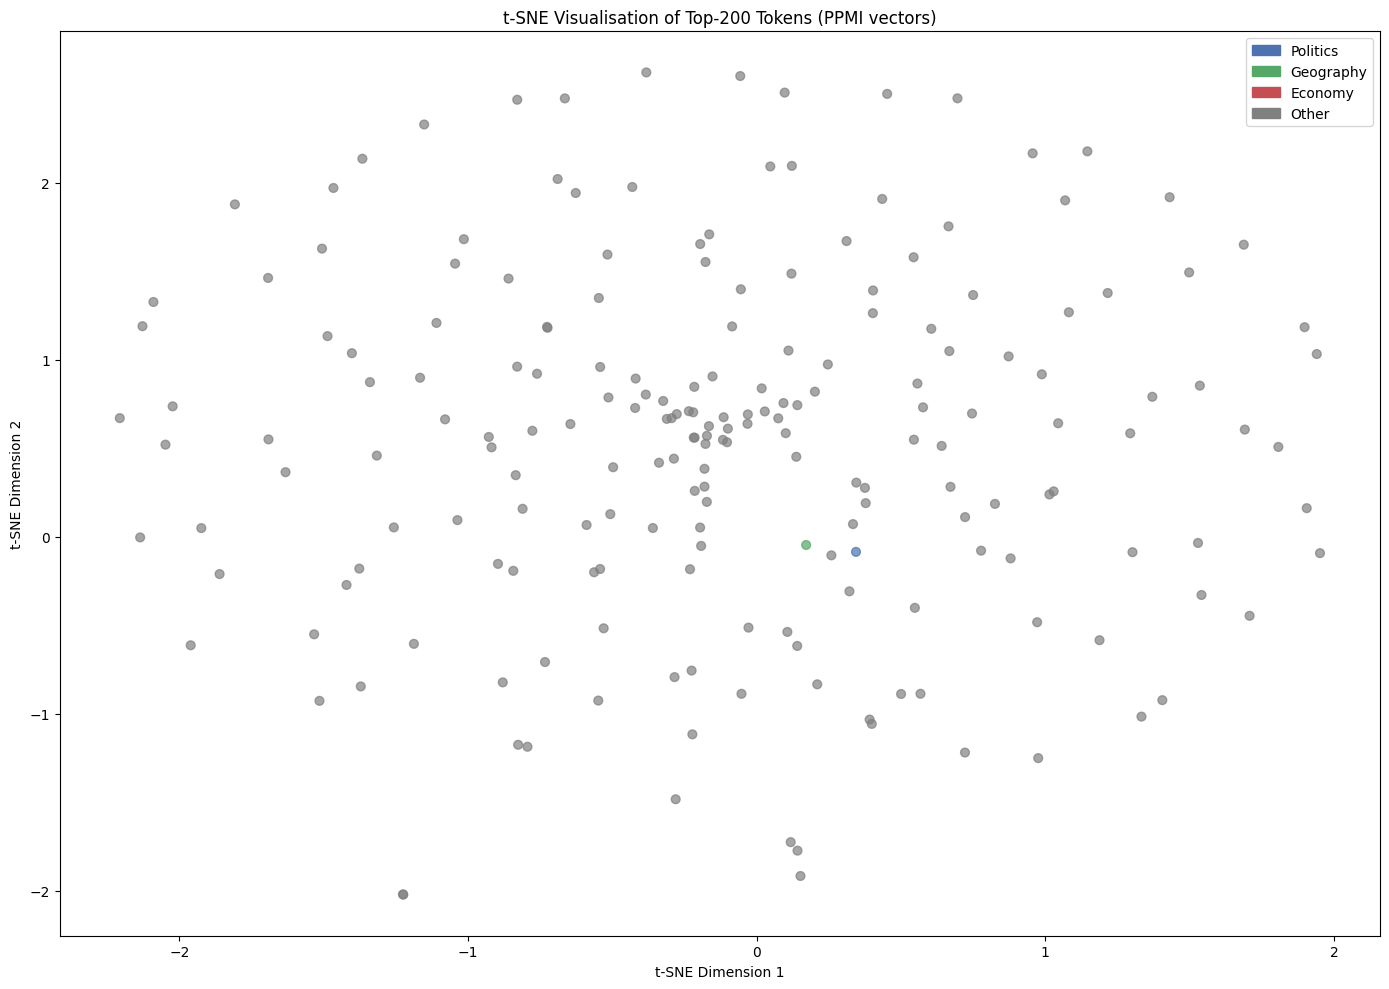

t-SNE plot saved.


In [7]:
TOP_N = 200
top_indices = [word2idx[w] for w, _ in token_freq.most_common(TOP_N) if word2idx.get(w, 1) < PPMI_VOCAB]
top_indices = top_indices[:TOP_N]
top_words   = [vocab_tokens[i] for i in top_indices]
top_vecs    = ppmi_matrix[top_indices]

word_to_cat = {}

politics_kw = ['حکومت', 'وزیر', 'پارلیمان', 'الیکشن', 'ووٹ', 'سیاسی', 'وزیراعظم', 'اسمبلی', 'عدالت', 'قانون']
geo_kw = ['پاکستان', 'ملاکنڈ', 'سوات', 'پشاور', 'خیبر', 'افغانستان', 'دیر', 'چترال']
economy_kw = ['بجلی', 'نیٹ', 'سولر', 'ٹیرف', 'قیمت', 'بلنگ', 'میٹرنگ', 'نیپرا']

for w in politics_kw: word_to_cat[w] = 'Politics'
for w in geo_kw:      word_to_cat[w] = 'Geography'
for w in economy_kw:  word_to_cat[w] = 'Economy'

cat_colors = {'Politics':'#4C72B0','Geography':'#55A868','Economy':'#C44E52','Other':'#808080'}
colors = [cat_colors.get(word_to_cat.get(w,'Other'),'#808080') for w in top_words]

tsne = TSNE(n_components=2, random_state=42, perplexity=30)
coords = tsne.fit_transform(top_vecs)

fig, ax = plt.subplots(figsize=(14, 10))
ax.scatter(coords[:,0], coords[:,1], c=colors, s=40, alpha=0.7)

handles = [mpatches.Patch(color=v, label=k) for k,v in cat_colors.items()]
ax.legend(handles=handles, loc='upper right')
ax.set_title('t-SNE Visualisation of Top-200 Tokens (PPMI vectors)')
ax.set_xlabel('t-SNE Dimension 1')
ax.set_ylabel('t-SNE Dimension 2')
plt.tight_layout()
plt.savefig('ppmi_tsne.png', dpi=150)
plt.show()
print('t-SNE plot saved.')

In [8]:
def cosine_sim_matrix(mat):
    norms = np.linalg.norm(mat, axis=1, keepdims=True) + 1e-10
    return (mat / norms) @ (mat / norms).T

sim = cosine_sim_matrix(ppmi_matrix[:PPMI_VOCAB])

query_words_ppmi = ['پاکستان','فوج','سوات','پولیس','بجلی','حکومت','علاقہ','امن','سولر','شدت']

print('Top-5 nearest neighbours (PPMI cosine similarity):\n')
for qw in query_words_ppmi:
    idx = word2idx.get(qw)
    if idx is None or idx >= PPMI_VOCAB:
        print(f'  {qw}: not in PPMI vocab'); continue
    scores = sim[idx].copy()
    scores[idx] = -1
    top5 = np.argsort(scores)[-5:][::-1]
    print(f'  {qw}: {[vocab_tokens[i] for i in top5]}')

Top-5 nearest neighbours (PPMI cosine similarity):

  پاکستان: ['انڈیا', 'ٹیم', 'کے', 'کرکٹ', 'میں']
  فوج: ['فوجی', 'ایرانی', 'کے', 'افواج', 'افسر']
  سوات: ['اپر', 'فالٹ', 'آدھی', 'پختونخوا', 'مہلک']
  پولیس: ['افسر', 'نے', 'درج', 'بتایا', 'سٹیشن']
  بجلی: ['سولر', 'گرڈ', 'کھپت', 'میٹرنگ', 'بلنگ']
  حکومت: ['کے', 'اور', 'کی', 'کو', 'پاکستان']
  علاقہ: ['کے', 'میں', 'شہر', 'اور', 'واقع']
  امن: ['غزہ', 'کمیٹی', 'امان', 'قایم', 'فلسطینی']
  سولر: ['میٹرنگ', 'بجلی', 'بلنگ', 'گرڈ', 'نان']
  شدت: ['پسند', 'پسندی', 'تنظیم', 'عسکریت', 'بلوچ']


## 2. Skip-gram Word2Vec 

In [ ]:
WINDOW_W2V = 5
K_NEG      = 10   
D_EMBED    = 100

freq_arr = np.array([token_freq.get(w, 0) for w in vocab_tokens], dtype=np.float64)
freq_arr[0] = 0  
noise_dist = freq_arr ** 0.75
noise_dist /= noise_dist.sum()
noise_dist_tensor = torch.tensor(noise_dist, dtype=torch.float32)

class SkipGramDataset(Dataset):
    def __init__(self, docs, w2i, window, k_neg, noise_dist):
        self.pairs = []
        for doc in docs:
            ids = [w2i.get(t, 1) for t in doc.split()]
            for i, center in enumerate(ids):
                lo = max(0, i - window)
                hi = min(len(ids), i + window + 1)
                for j in range(lo, hi):
                    if i != j:
                        self.pairs.append((center, ids[j]))
        self.noise = noise_dist
        self.k = k_neg
        self.n = len(self.noise)
        print(f'  Training pairs: {len(self.pairs):,}')

    def __len__(self): return len(self.pairs)

    def __getitem__(self, idx):
        center, pos = self.pairs[idx]
        neg = torch.multinomial(self.noise, self.k, replacement=True)
        return torch.tensor(center), torch.tensor(pos), neg

print('Building training dataset on cleaned.txt...')
dataset    = SkipGramDataset(cleaned_docs, word2idx, WINDOW_W2V, K_NEG, noise_dist_tensor)
dataloader = DataLoader(dataset, batch_size=512, shuffle=True, num_workers=0 , pin_memory= True)

Building training dataset on cleaned.txt...
  Training pairs: 4,669,010


In [ ]:
class SkipGram(nn.Module):
    def __init__(self, vocab_size, d=100):
        super().__init__()
        self.V = nn.Embedding(vocab_size, d)  
        self.U = nn.Embedding(vocab_size, d)  
        nn.init.uniform_(self.V.weight, -0.5/d, 0.5/d)
        nn.init.zeros_(self.U.weight)

    def forward(self, center, pos_ctx, neg_ctx):
        vc  = self.V(center)        
        uo  = self.U(pos_ctx)        
        un  = self.U(neg_ctx)       

        pos_score = (uo * vc).sum(-1)                  
        neg_score = (un * vc.unsqueeze(1)).sum(-1)        

        pos_loss  = F.logsigmoid(pos_score)
        neg_loss  = F.logsigmoid(-neg_score).sum(-1)
        return -(pos_loss + neg_loss).mean()

model_w2v  = SkipGram(V, D_EMBED).to(device)
optimizer  = torch.optim.Adam(model_w2v.parameters(), lr=0.001)
print(f'Model parameters: {sum(p.numel() for p in model_w2v.parameters()):,}')

Model parameters: 2,000,000


  Epoch 1 step    0/9120 loss=7.6246
  Epoch 1 step  200/9120 loss=4.3724
  Epoch 1 step  400/9120 loss=3.6434
  Epoch 1 step  600/9120 loss=3.4302
  Epoch 1 step  800/9120 loss=3.3484
  Epoch 1 step 1000/9120 loss=3.2134
  Epoch 1 step 1200/9120 loss=3.2356
  Epoch 1 step 1400/9120 loss=3.2171
  Epoch 1 step 1600/9120 loss=3.2698
  Epoch 1 step 1800/9120 loss=3.1954
  Epoch 1 step 2000/9120 loss=3.2067
  Epoch 1 step 2200/9120 loss=3.1908
  Epoch 1 step 2400/9120 loss=3.2092
  Epoch 1 step 2600/9120 loss=3.1982
  Epoch 1 step 2800/9120 loss=3.1665
  Epoch 1 step 3000/9120 loss=3.1705
  Epoch 1 step 3200/9120 loss=3.1695
  Epoch 1 step 3400/9120 loss=3.1714
  Epoch 1 step 3600/9120 loss=3.1293
  Epoch 1 step 3800/9120 loss=3.1104
  Epoch 1 step 4000/9120 loss=3.1412
  Epoch 1 step 4200/9120 loss=3.1026
  Epoch 1 step 4400/9120 loss=3.1673
  Epoch 1 step 4600/9120 loss=3.0916
  Epoch 1 step 4800/9120 loss=3.1230
  Epoch 1 step 5000/9120 loss=3.0772
  Epoch 1 step 5200/9120 loss=3.0880
 

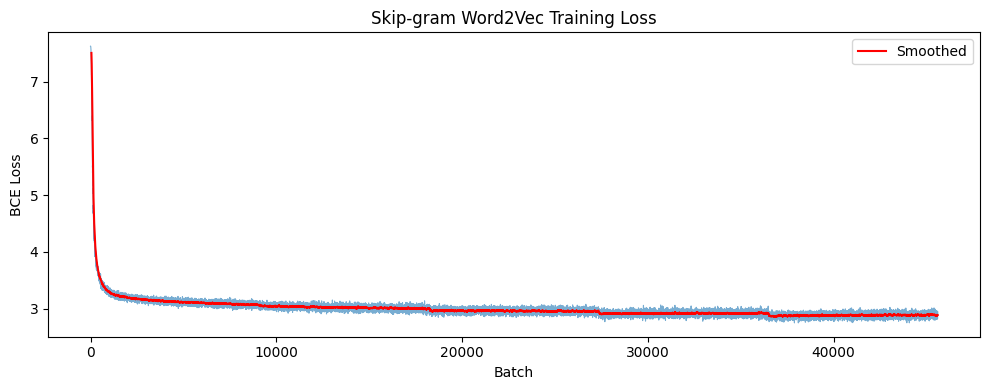

In [11]:
EPOCHS = 5
loss_history = []

for epoch in range(EPOCHS):
    model_w2v.train()
    epoch_loss = 0.0
    n_batches  = 0
    for step, (center, pos, neg) in enumerate(dataloader):
        center = center.to(device)
        pos    = pos.to(device)
        neg    = neg.to(device)
        loss   = model_w2v(center, pos, neg)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        epoch_loss += loss.item()
        n_batches  += 1
        if step % 200 == 0:
            print(f'  Epoch {epoch+1} step {step:4d}/{len(dataloader)} loss={loss.item():.4f}')
        loss_history.append(loss.item())
    print(f'Epoch {epoch+1}/{EPOCHS} — avg loss: {epoch_loss/n_batches:.4f}')

emb_avg = 0.5 * (model_w2v.V.weight + model_w2v.U.weight)
emb_np  = emb_avg.detach().cpu().numpy()
np.save('embeddings/embeddings_w2v.npy', emb_np)
print('Embeddings saved: embeddings/embeddings_w2v.npy', emb_np.shape)

plt.figure(figsize=(10, 4))
plt.plot(loss_history, alpha=0.6, linewidth=0.8)
smooth = np.convolve(loss_history, np.ones(50)/50, mode='valid')
plt.plot(range(49, 49+len(smooth)), smooth, color='red', linewidth=1.5, label='Smoothed')
plt.xlabel('Batch')
plt.ylabel('BCE Loss')
plt.title('Skip-gram Word2Vec Training Loss')
plt.legend()
plt.tight_layout()
plt.savefig('w2v_loss_curve.png', dpi=150)
plt.show()

In [12]:
emb = torch.tensor(emb_np)
emb_norm = F.normalize(emb, dim=1)

def top_k_neighbours(word, k=10):
    idx = word2idx.get(word)
    if idx is None:
        return []
    scores = (emb_norm[idx] @ emb_norm.T).numpy()
    scores[idx] = -1
    top = np.argsort(scores)[-k:][::-1]
    return [(vocab_tokens[i], round(float(scores[i]), 4)) for i in top]

required_queries = ['پاکستان','حکومت','عدالت','معیشت','فوج','صحت','تعلیم','آبادی']
print('Top-10 nearest neighbours (Word2Vec):\n')
for qw in required_queries:
    nn_list = top_k_neighbours(qw, 10)
    print(f'  {qw}: {[w for w,_ in nn_list]}')

Top-10 nearest neighbours (Word2Vec):

  پاکستان: ['ٹونٹی', 'مندوب', 'فلاور', 'پریماداسا', 'انڈیا', 'آییڈل', 'امپایرنگ', 'انڈر', 'کولمبو', 'ہالینڈ']
  حکومت: ['تابع', 'صوبایی', 'عبوری', 'تختہ', 'نت', 'انصاف', 'الٹنے', 'ڈیموکریٹس', 'مخلوط', 'وفاقی']
  عدالت: ['جع', 'جج', 'کورٹ', 'سٹینر', 'ویرن', 'مقدمے', 'سوالنامہ', 'پراسیکیوٹر', 'سپریم', 'استفسار']
  معیشت: ['روکی', 'ترقی', 'معاشی', 'گزرگاہ', 'ٹلنے', 'روزگاری', 'مضبوطی', 'ریڑھ', 'سرمایہ', 'خوشحالی']
  فوج: ['ایرانی', 'اینگلو', 'افواج', 'مارکسسٹ', 'فوجی', 'دست', 'کچنر', 'سپاہی', 'کمان', 'بغاوت']
  صحت: ['یابی', 'نوعمر', 'مند', 'نیند', 'تولیدی', 'نشوونما', 'ذہنی', 'غذا', 'یاب', 'کاونسلنگ']
  تعلیم: ['سیکنڈری', 'گذستہ', 'کالج', 'ٹیکنیکل', 'انجینییرنگ', 'یونیورسٹی', 'بیکن', 'پولی', 'ہایر', 'نسخ']
  آبادی: ['ناخواندہ', 'میزورم', 'تقریبا', 'پانچواں', 'کنٹری', 'دیبہ', 'پندرہ', 'جتھہ', 'حجم', 'ڈویلپنگ']


In [ ]:
def analogy(a, b, c, k=3):
    for w in [a, b, c]:
        if word2idx.get(w) is None:
            return None
    va = emb_norm[word2idx[a]]
    vb = emb_norm[word2idx[b]]
    vc = emb_norm[word2idx[c]]
    query = F.normalize((vb - va + vc).unsqueeze(0), dim=1).squeeze()
    scores = (emb_norm @ query).numpy()
    for w in [a, b, c]:
        scores[word2idx[w]] = -1
    top = np.argsort(scores)[-k:][::-1]
    return [vocab_tokens[i] for i in top]


analogy_tests = [
    ('عدالت', 'جج', 'ہسپتال'),        # عدالت : جج :: ہسپتال : ڈاکٹر
    ('ہسپتال', 'ڈاکٹر', 'عدالت'),      # ہسپتال : ڈاکٹر :: عدالت : جج
    ('عدالت', 'وکیل', 'ہسپتال'),      # عدالت : وکیل :: ہسپتال : ڈاکٹر
    ('ہسپتال', 'علاج', 'عدالت'),      # ہسپتال : علاج :: عدالت : انصاف
    ('عدالت', 'انصاف', 'ہسپتال'),     # عدالت : انصاف :: ہسپتال : علاج
    ('پولیس', 'تفتیش', 'عدالت'),      # پولیس : تفتیش :: عدالت : مقدمہ
    ('عدالت', 'مقدمہ', 'ہسپتال'),     # عدالت : مقدمہ :: ہسپتال : علاج
    ('سکول', 'تعلیم', 'ہسپتال'),      # سکول : تعلیم :: ہسپتال : علاج
    ('ہسپتال', 'مریض', 'عدالت'),      # ہسپتال : مریض :: عدالت : مقدمہ
    ('پولیس', 'امن', 'عدالت'),        # پولیس : امن :: عدالت : انصاف
]

print('Analogy tests (a : b :: c : ?):\n')
for a, b, c in analogy_tests:
    result = analogy(a, b, c)
    if result:
        print(f'  {a} : {b} :: {c} : {result}')
    else:
        print(f'  (word not in vocab: {a},{b},{c})')

Analogy tests (a : b :: c : ?):

  عدالت : جج :: ہسپتال : ['پمز', 'ناگپور', 'ماتارا']
  ہسپتال : ڈاکٹر :: عدالت : ['چال', 'بارہا', 'جج']
  عدالت : وکیل :: ہسپتال : ['ویٹرو', 'سرجن', 'ناگپور']
  ہسپتال : علاج :: عدالت : ['مقدمے', 'جع', 'ٹرایل']
  عدالت : انصاف :: ہسپتال : ['آپریٹرز', 'علاج', 'صحت']
  پولیس : تفتیش :: عدالت : ['امتناع', 'استفسار', 'مقدمے']
  عدالت : مقدمہ :: ہسپتال : ['ریٹی', 'وارڈ', 'علاج']
  سکول : تعلیم :: ہسپتال : ['پمز', 'علاج', 'پیرا']
  ہسپتال : مریض :: عدالت : ['ریلیف', 'مقدمے', 'پرنٹ']
  پولیس : امن :: عدالت : ['غزہ', 'منصوب', 'فیصلہ']


To Some Extent Embbedings Capture Meaning full Semantics, But due to Token `<UNK>` the training is effected and we can see some hallucination between words during anology test and nearest neighbour test.

---
# Part 2 — Sequence Labeling: POS Tagging & NER

## 3. Dataset Preparation

In [ ]:
POS_TAGS = ['NOUN','VERB','ADJ','ADV','PRON','DET','CONJ','POST','NUM','PUNC','UNK']
NER_TAGS = ['O','B-PER','I-PER','B-LOC','I-LOC','B-ORG','I-ORG','B-MISC','I-MISC']

pos2idx = {t:i for i,t in enumerate(POS_TAGS)}
ner2idx = {t:i for i,t in enumerate(NER_TAGS)}
idx2pos = {i:t for t,i in pos2idx.items()}
idx2ner = {i:t for t,i in ner2idx.items()}

PERSONS   = {'عمران خان','شہباز شریف','آصف زرداری','مولانا فضل الرحمن',
             'محسن نقوی','سہیل آفریدی','اختر علی شاہ','عدنان باچا',
             'لحاظ علی','علی اکبر','شفیع جان','آفتاب عالم',
             'عمر احمد بخاری','بلاول بھٹو','مریم نواز',
             'چودھری نثار','شیخ رشید','سراج الحق','سیف اللہ نیازی',
             'یوسف رضا گیلانی','شوکت عزیز','پرویز مشرف','ضیاء الحق',
             'فضل الرحمن','عبداللہ شاہ','غلام احمد بلور','امیر حیدر',
             'جاوید لطیف','شیری رحمان','فواد چودھری','تارڑ صاحب',
             'ناصر حسین شاہ','سردار اختر مینگل','اسد قیصر','علی امین گنڈاپور',
             'محمد علی','احمد شاہ','حامد میر','اعزاز سید',
             'کامران خان','طلعت حسین','صابر شاکر','رانا ثناء اللہ',
             'خواجہ آصف','احسن اقبال','سعد رفیق','قمر جاوید باجوہ'}

LOCATIONS = {'پاکستان','اسلام آباد','کراچی','لاہور','پشاور','کوئٹہ','راولپنڈی',
             'سوات','ملاکنڈ','خیبر پختونخوا','سندھ','پنجاب','بلوچستان',
             'افغانستان','بھارت','چین','امریکہ','ایران','روس',
             'دیر','باجوڑ','بونیر','شانگلہ','چترال','مٹہ','خیبر',
             'کرم','وزیرستان','مہمند','اورکزئی','موہمند',
             'گلگت','مظفرآباد','میرپور','لاہور','ملتان','فیصل آباد',
             'گوادر','حیدرآباد','سکھر','قصور','شیخوپورہ',
             'ننکانہ صاحب','گجرات','گوجرانوالہ','ساہیوال',
             'اٹک','چکوال','جہلم','سرگودھا','بہاولپور','رحیم یار خان'}

ORGS      = {'پاکستانی فوج','آئی ایس آئی','پاکستان تحریک انصاف','مسلم لیگ',
             'پیپلز پارٹی','جمعیت علماء اسلام','نیپرا','سی ٹی ڈی',
             'ٹی ٹی پی','تحریک طالبان','اقوام متحدہ','بی بی سی',
             'سپریم کورٹ','الیکشن کمیشن','نیب','ایف آئی اے',
             'ریاست مدینہ','وفاقی حکومت','صوبائی حکومت','ایپکس کمیٹی',
             'پی ایس ایل','پاکستان کرکٹ بورڈ','ورلڈ بینک','آئی ایم ایف',
             'امریکی سفارت خانہ','یورپی یونین','نیٹو','شنگھائی تعاون تنظیم'}

print(f'Gazetteer — Persons: {len(PERSONS)}, Locations: {len(LOCATIONS)}, Orgs: {len(ORGS)}')

Gazetteer — Persons: 47, Locations: 51, Orgs: 28


In [ ]:
NOUN_LEX  = {'پاکستان','حکومت','وزیر','فوج','پولیس','علاقہ','صوبہ','ملاکنڈ',
             'سوات','دیر','باجوڑ','آپریشن','امن','شدت','کنٹرول','فیصلہ',
             'اجلاس','اعلامیہ','ذمہ داری','صلاحیت','انتظامیہ','سکیورٹی',
             'قانون','ادارہ','تربیت','وسائل','اسلحہ','انٹیلیجنس',
             'سرحد','علاقہ','لوگ','عوام','شہری','ریلی','مطالبہ',
             'بجلی','سولر','نیپرا','ٹیرف','صارف','بلنگ','میٹرنگ',
             'قیمت','توانائی','گرڈ','نظام','کمیٹی','رپورٹ','پشاور',
             'ملک','دنیا','شہر','گاؤں','دریا','پہاڑ','رات','دن',
             'سال','مہینہ','ہفتہ','وقت','جگہ','راستہ','خبر','بیان',
             'ادارہ','تنظیم','پارٹی','انتخابات','ووٹ','نتیجہ','حق'}

VERB_LEX  = {'کیا','کی','کریں','ہے','ہیں','تھا','تھی','تھے','ہوا','ہوئی','ہوں',
             'کرنا','کرتے','کہا','کہتے','دیا','دی','لیا','لی','آیا',
             'گیا','گئی','گئے','جائے','جاتا','بنایا','بنائی','دیکھا',
             'کریں گے','ملے','ملی','رہا','رہی','رہے','چاہیے','چاہتا',
             'سکتا','سکتی','سکتے','ہوگا','ہوگی','ہوں گے','آئے','چلے'}

ADJ_LEX   = {'بڑا','چھوٹا','نیا','پرانا','اہم','خاص','عام','مشہور','سخت',
             'کشیدہ','بہتر','خراب','مضبوط','کمزور','تیز','سست','گرم','ٹھنڈا',
             'صوبائی','وفاقی','مقامی','قبائلی','مسلح','جدید','ملکی','غیر ملکی',
             'پاکستانی','افغانی','بھارتی','امریکی','سیاسی','فوجی','سول'}

ADV_LEX   = {'اب','پھر','پہلے','بعد','یہاں','وہاں','ہمیشہ','کبھی','جلدی',
             'آہستہ','ضرور','شاید','فوری','مکمل طور پر','بالکل','صرف'}

PRON_LEX  = {'وہ','یہ','ہم','آپ','تم','میں','انھوں','انہوں','اس','ان','جو','جن'}

DET_LEX   = {'ایک','دو','تین','وہ','یہ','کوئی','کچھ','سب','ہر','بعض','تمام'}

CONJ_LEX  = {'اور','لیکن','یا','کیونکہ','جب','تو','اگر','مگر','بلکہ','نہ','بھی'}

POST_LEX  = {'میں','سے','کے','کی','کا','نے','پر','تک','کو','لیے','ساتھ','بارے'}

NUM_LEX   = {'ایک','دو','تین','چار','پانچ','دس','سو','ہزار','لاکھ','کروڑ',
             '١','٢','٣','٤','٥','٦','٧','٨','٩','٠',
             '1','2','3','4','5','6','7','8','9','0'}

PUNC_SET  = set('،۔؟!:;()[]{}،.?!:"«»')
VERB_SUFFIXES = ('نا','تا','تی','تے','گا','گی','گے','ئیں')
ADJ_SUFFIXES  = ('ی','دار','مند','انہ')
LOC_SUFFIXES  = ('آباد','ستان','پور','گڑھ','وال')
PERSON_SUFFIX_TOKENS = {'خان','شریف','علی','احمد','حسین','رحمان','نواز','قیصر','اقبال','رفیق','اللہ','امین'}

CLOSED_CLASS = PRON_LEX | DET_LEX | CONJ_LEX | POST_LEX | NUM_LEX
auto_noun_candidates = []
for w, _ in token_freq.most_common(4000):
    if (len(w) >= 3 and
        w not in CLOSED_CLASS and
        w not in VERB_LEX and
        w not in ADJ_LEX and
        w not in ADV_LEX and
        not any(ch.isdigit() for ch in w) and
        w not in PUNC_SET):
        auto_noun_candidates.append(w)
NOUN_LEX.update(auto_noun_candidates[:1200])

def normalize_token(word):
    return word.strip(''.join(PUNC_SET))

def pos_tag(word, prev_word=None, next_word=None):
    w = normalize_token(word)
    if not w:
        return 'PUNC'
    if w in PUNC_SET or all(c in PUNC_SET for c in w):
        return 'PUNC'
    if any(c.isdigit() or c in '٠١٢٣٤٥٦٧٨٩' for c in w):
        return 'NUM'
    if w in NOUN_LEX or w in PERSONS or w in LOCATIONS or w in ORGS:
        return 'NOUN'
    if w in VERB_LEX:
        return 'VERB'
    if w in ADJ_LEX:
        return 'ADJ'
    if w in ADV_LEX:
        return 'ADV'
    if w in PRON_LEX:
        return 'PRON'
    if w in DET_LEX:
        return 'DET'
    if w in CONJ_LEX:
        return 'CONJ'
    if w in POST_LEX:
        return 'POST'
    if w in NUM_LEX:
        return 'NUM'
    if next_word in POST_LEX or prev_word in DET_LEX:
        return 'NOUN'
    if w.endswith(VERB_SUFFIXES):
        return 'VERB'
    if w.endswith(ADJ_SUFFIXES) and len(w) > 3:
        return 'ADJ'
    if w.endswith(LOC_SUFFIXES):
        return 'NOUN'
    if any(part in PERSON_SUFFIX_TOKENS for part in w.split()):
        return 'NOUN'
    if len(w) <= 1:
        return 'UNK'
    return 'NOUN'

def pos_tag_sentence(tokens):
    tags = []
    for i, tok in enumerate(tokens):
        prev_word = tokens[i-1] if i > 0 else None
        next_word = tokens[i+1] if i + 1 < len(tokens) else None
        tags.append(pos_tag(tok, prev_word=prev_word, next_word=next_word))
    return tags

print('Rule-based POS tagger ready.')
# Quick test
test_sent = 'فوج ملاکنڈ میں آپریشن کیا'
for tok, tg in zip(test_sent.split(), pos_tag_sentence(test_sent.split())):
    print(f'  {tok} -> {tg}')

Rule-based POS tagger ready.
  فوج -> NOUN
  ملاکنڈ -> NOUN
  میں -> PRON
  آپریشن -> NOUN
  کیا -> VERB


In [ ]:
ORG_HINT_TOKENS = {'پارٹی','فوج','حکومت','عدالت','کمیشن','کمیٹی','بینک','بورڈ','وزارت','یونین','ادارہ','تنظیم'}
PERSON_TITLE_TOKENS = {'وزیراعظم','وزیر','صدر','چیئرمین','جنرل','میاں','مولانا','ڈاکٹر','جج','کپتان'}
LOC_POSTPOSITIONS = {'میں','سے','تک','پر'}
LOC_SUFFIX_TOKENS = ('آباد','ستان','پور','گڑھ','وال')

def looks_like_location(token):
    return token in LOCATIONS or token.endswith(LOC_SUFFIX_TOKENS)

def looks_like_org(span):
    return any(h in span for h in ORG_HINT_TOKENS)

def ner_tag_sentence(tokens):
    tags = ['O'] * len(tokens)
    i = 0
    while i < len(tokens):
        matched = False
        for span_len in range(min(4, len(tokens)-i), 0, -1):
            span = ' '.join(tokens[i:i+span_len])
            if span in PERSONS:
                tags[i] = 'B-PER'
                for j in range(1, span_len):
                    tags[i+j] = 'I-PER'
                i += span_len; matched = True; break
            elif span in LOCATIONS:
                tags[i] = 'B-LOC'
                for j in range(1, span_len):
                    tags[i+j] = 'I-LOC'
                i += span_len; matched = True; break
            elif span in ORGS:
                tags[i] = 'B-ORG'
                for j in range(1, span_len):
                    tags[i+j] = 'I-ORG'
                i += span_len; matched = True; break
        if not matched:
            tok = tokens[i]
            nxt = tokens[i+1] if i + 1 < len(tokens) else ''
            if tok in PERSON_TITLE_TOKENS and nxt:
                tags[i] = 'B-PER'
                tags[i+1] = 'I-PER'
                i += 2
                continue
            if looks_like_location(tok) or (nxt in LOC_POSTPOSITIONS and len(tok) > 2):
                tags[i] = 'B-LOC'
                i += 1
                continue
            if looks_like_org(tok):
                tags[i] = 'B-ORG'
                i += 1
                continue
            if pos_tag(tok) == 'NOUN' and len(tok) >= 4:
                tags[i] = 'B-MISC'
            i += 1
    return tags

# Test
sample = 'محسن نقوی نے پشاور میں اجلاس کیا'.split()
print('NER test:')
for tok, tag in zip(sample, ner_tag_sentence(sample)):
    print(f'  {tok:20s} {tag}')

NER test:
  محسن                 B-PER
  نقوی                 I-PER
  نے                   O
  پشاور                B-LOC
  میں                  O
  اجلاس                B-MISC
  کیا                  O


In [29]:
def split_sentences(text):
    # Split on Urdu sentence-ending punctuation
    parts = re.split(r'[۔.!?؟]+', text)
    return [p.strip() for p in parts if len(p.strip().split()) >= 3]

def sentence_entity_score(sentence):
    tokens = sentence.split()
    if len(tokens) < 3:
        return -1.0
    ner_tags = ner_tag_sentence(tokens)
    ent_hits = sum(t != 'O' for t in ner_tags)
    noun_hits = sum(pos_tag(t) == 'NOUN' for t in tokens)
    bonus = 0.0
    if any(t in PERSON_TITLE_TOKENS for t in tokens):
        bonus += 2.0
    if any(t in ORG_HINT_TOKENS for t in tokens):
        bonus += 1.5
    return ((3.0 * ent_hits) + (0.25 * noun_hits) + bonus) / max(1, len(tokens))

scored_sentences = []
for str_id, meta in metadata.items():
    idx = int(str_id) - 1
    if idx < len(cleaned_docs):
        sents = split_sentences(cleaned_docs[idx])
        for s in sents:
            scored_sentences.append((s, meta['category'], sentence_entity_score(s)))

# Entity-dense stratified sample
cat_sents = defaultdict(list)
for s, cat, score in scored_sentences:
    cat_sents[cat].append((s, cat, score))
for cat in categories:
    cat_sents[cat].sort(key=lambda x: x[2], reverse=True)

TARGET_TOTAL = 500
BASE_PER_CAT = max(40, TARGET_TOTAL // max(1, len(categories)) // 2)
selected = []
used = set()
for cat in categories:
    pool = cat_sents.get(cat, [])
    n = min(len(pool), max(BASE_PER_CAT, min(120, len(pool))))
    for s, c, _ in pool[:n]:
        key = (s, c)
        if key not in used:
            selected.append((s, c))
            used.add(key)

# Fill remaining slots with highest-scoring sentences globally.
if len(selected) < TARGET_TOTAL:
    for s, c, _ in sorted(scored_sentences, key=lambda x: x[2], reverse=True):
        key = (s, c)
        if key in used:
            continue
        selected.append((s, c))
        used.add(key)
        if len(selected) >= TARGET_TOTAL:
            break

selected = selected[:TARGET_TOTAL]
random.shuffle(selected)
avg_entity_score = np.mean([sentence_entity_score(s) for s, _ in selected]) if selected else 0.0
print(f'Selected {len(selected)} sentences')
print(f'Average entity score: {avg_entity_score:.3f}')
for cat in categories:
    n = sum(1 for _,c in selected if c==cat)
    print(f'  {cat}: {n}')

Selected 500 sentences
Average entity score: 2.037
  Economy: 118
  Health & Society: 120
  International: 120
  Others: 118
  Politics: 24
  Sports: 0


In [ ]:
annotated = []
for sent, cat in selected:
    tokens   = sent.split()
    pos_tags = pos_tag_sentence(tokens)
    ner_tags = ner_tag_sentence(tokens)
    annotated.append((tokens, pos_tags, ner_tags, cat))

# Stratified split 70/15/15
from sklearn.model_selection import train_test_split
labels_for_split = [a[3] for a in annotated]
train_data, temp = train_test_split(annotated, test_size=0.30, stratify=labels_for_split, random_state=42)
labs_temp = [a[3] for a in temp]
val_data, test_data = train_test_split(temp, test_size=0.50, stratify=labs_temp, random_state=42)

print(f'Train: {len(train_data)}, Val: {len(val_data)}, Test: {len(test_data)}')

def write_conll(data, path_pos, path_ner):
    with open(path_pos,'w',encoding='utf-8') as fp, \
         open(path_ner,'w',encoding='utf-8') as fn:
        for tokens, pos_tags, ner_tags, _ in data:
            for t, p, n in zip(tokens, pos_tags, ner_tags):
                fp.write(f'{t}\t{p}\n')
                fn.write(f'{t}\t{n}\n')
            fp.write('\n'); fn.write('\n')

write_conll(train_data, 'data/pos_train.conll', 'data/ner_train.conll')
write_conll(test_data,  'data/pos_test.conll',  'data/ner_test.conll')
print('CoNLL files written.')

# Class distribution
pos_dist = Counter(t for _,pts,_,_ in annotated for t in pts)
ner_dist = Counter(t for _,_,nts,_ in annotated for t in nts)
print('\nPOS distribution:', dict(pos_dist.most_common()))
print('NER distribution:', dict(ner_dist.most_common()))
total_tokens = sum(len(tokens) for tokens, _, _, _ in annotated)
unk_ratio = (pos_dist.get('UNK', 0) / total_tokens) if total_tokens else 0.0
o_ratio = (ner_dist.get('O', 0) / total_tokens) if total_tokens else 0.0
print(f'UNK ratio: {unk_ratio:.3%} | O ratio: {o_ratio:.3%}')

Train: 350, Val: 75, Test: 75
CoNLL files written.

POS distribution: {'NOUN': 6217, 'POST': 1075, 'VERB': 878, 'PRON': 423, 'CONJ': 240, 'ADJ': 142, 'PUNC': 106, 'DET': 65, 'ADV': 41, 'NUM': 22, 'UNK': 13}
NER distribution: {'B-MISC': 4361, 'O': 3760, 'B-LOC': 683, 'B-ORG': 159, 'I-ORG': 87, 'I-PER': 83, 'B-PER': 82, 'I-LOC': 7}
UNK ratio: 0.141% | O ratio: 40.772%


## 4. BiLSTM Sequence Labeler

In [ ]:
class SeqLabelDataset(Dataset):
    def __init__(self, data, w2i, tag2i, task='pos'):
        self.samples = []
        for tokens, pos_tags, ner_tags, _ in data:
            ids  = [w2i.get(t, w2i['<UNK>']) for t in tokens]
            tags = [tag2i.get(t, 0) for t in (pos_tags if task=='pos' else ner_tags)]
            if ids:
                self.samples.append((ids, tags))

    def __len__(self): return len(self.samples)
    def __getitem__(self, idx): return self.samples[idx]

def collate_fn(batch):
    ids_list, tags_list = zip(*batch)
    lengths = torch.tensor([len(x) for x in ids_list])
    max_len = lengths.max().item()
    ids_pad  = torch.zeros(len(batch), max_len, dtype=torch.long)
    tags_pad = torch.full((len(batch), max_len), -1, dtype=torch.long)  # -1 = pad
    for i, (ids, tags) in enumerate(zip(ids_list, tags_list)):
        ids_pad[i, :len(ids)]   = torch.tensor(ids)
        tags_pad[i, :len(tags)] = torch.tensor(tags)
    return ids_pad, tags_pad, lengths

# POS datasets
pos_train_ds = SeqLabelDataset(train_data, word2idx, pos2idx, 'pos')
pos_val_ds   = SeqLabelDataset(val_data,   word2idx, pos2idx, 'pos')
pos_test_ds  = SeqLabelDataset(test_data,  word2idx, pos2idx, 'pos')

pos_train_dl = DataLoader(pos_train_ds, batch_size=32, shuffle=True,  collate_fn=collate_fn)
pos_val_dl   = DataLoader(pos_val_ds,   batch_size=32, shuffle=False, collate_fn=collate_fn)
pos_test_dl  = DataLoader(pos_test_ds,  batch_size=32, shuffle=False, collate_fn=collate_fn)

# NER datasets
ner_train_ds = SeqLabelDataset(train_data, word2idx, ner2idx, 'ner')
ner_val_ds   = SeqLabelDataset(val_data,   word2idx, ner2idx, 'ner')
ner_test_ds  = SeqLabelDataset(test_data,  word2idx, ner2idx, 'ner')

ner_train_dl = DataLoader(ner_train_ds, batch_size=32, shuffle=True,  collate_fn=collate_fn)
ner_val_dl   = DataLoader(ner_val_ds,   batch_size=32, shuffle=False, collate_fn=collate_fn)
ner_test_dl  = DataLoader(ner_test_ds,  batch_size=32, shuffle=False, collate_fn=collate_fn)

print('Datasets ready.')

Datasets ready.


In [ ]:
class BiLSTMTagger(nn.Module):
    def __init__(self, vocab_size, embed_dim, hidden_dim, num_tags,
                 pretrained_emb=None, freeze=True):
        super().__init__()
        self.embed = nn.Embedding(vocab_size, embed_dim, padding_idx=0)
        if pretrained_emb is not None:
            w = torch.tensor(pretrained_emb[:vocab_size], dtype=torch.float32)
            if w.shape[1] != embed_dim:
                w = w[:, :embed_dim]
            self.embed.weight.data.copy_(w)
            self.embed.weight.requires_grad = not freeze
        self.lstm = nn.LSTM(embed_dim, hidden_dim, num_layers=2,
                            bidirectional=True, dropout=0.5, batch_first=True)
        self.drop = nn.Dropout(0.5)
        self.fc   = nn.Linear(hidden_dim * 2, num_tags)

    def forward(self, x, lengths):
        emb    = self.drop(self.embed(x))
        packed = nn.utils.rnn.pack_padded_sequence(
            emb, lengths.cpu(), batch_first=True, enforce_sorted=False)
        out, _ = self.lstm(packed)
        out, _ = nn.utils.rnn.pad_packed_sequence(out, batch_first=True)
        return self.fc(self.drop(out))   # (B, T, num_tags)

print('BiLSTM model defined.')

BiLSTM model defined.


In [33]:
# ── CRF layer with learnable transition matrix ────────────────────────────
class CRF(nn.Module):
    def __init__(self, num_tags):
        super().__init__()
        self.num_tags = num_tags
        self.transitions      = nn.Parameter(torch.randn(num_tags, num_tags) * 0.1)
        self.start_transitions = nn.Parameter(torch.randn(num_tags) * 0.1)
        self.end_transitions   = nn.Parameter(torch.randn(num_tags) * 0.1)

    def _log_sum_exp(self, tensor, dim):
        m, _ = tensor.max(dim=dim, keepdim=True)
        return (tensor - m).exp().sum(dim=dim).log() + m.squeeze(dim)

    def forward(self, emissions, tags, mask):
        """Compute negative log-likelihood (CRF loss)."""
        B, T, C = emissions.shape
        # Score of correct path
        score = self.start_transitions[tags[:, 0]]
        score += emissions[torch.arange(B), 0, tags[:, 0]]
        for t in range(1, T):
            m = mask[:, t].bool()
            trans = self.transitions[tags[:, t-1], tags[:, t]]
            emit  = emissions[torch.arange(B), t, tags[:, t]]
            score = score + (trans + emit) * m.float()
        # End transition
        last_tag = tags[torch.arange(B), mask.sum(1).long()-1]
        score += self.end_transitions[last_tag]
        # Partition function (forward algorithm)
        alpha = self.start_transitions + emissions[:, 0]
        for t in range(1, T):
            m = mask[:, t].bool().unsqueeze(-1)
            emit  = emissions[:, t].unsqueeze(1)           # (B, 1, C)
            trans = self.transitions.unsqueeze(0)           # (1, C, C)
            new_alpha = self._log_sum_exp(alpha.unsqueeze(2) + trans + emit, dim=1)
            alpha = torch.where(m, new_alpha, alpha)
        alpha += self.end_transitions
        log_Z = self._log_sum_exp(alpha, dim=1)
        return (log_Z - score).mean()

    def viterbi_decode(self, emissions, mask):
        """Viterbi algorithm for inference."""
        B, T, C = emissions.shape
        viterbi     = self.start_transitions + emissions[:, 0]
        backpointers = []
        for t in range(1, T):
            trans = self.transitions.unsqueeze(0)            # (1, C, C)
            score = viterbi.unsqueeze(2) + trans             # (B, C, C)
            best_scores, best_tags = score.max(dim=1)        # (B, C)
            emit  = emissions[:, t]
            new_v = best_scores + emit
            m     = mask[:, t].bool().unsqueeze(-1)
            viterbi = torch.where(m, new_v, viterbi)
            backpointers.append(best_tags)
        viterbi += self.end_transitions
        _, best_last = viterbi.max(dim=1)
        # Backtrack
        best_paths = []
        lens = mask.sum(1).long()
        for b in range(B):
            path = [best_last[b].item()]
            for bp in reversed(backpointers):
                path.append(bp[b][path[-1]].item())
            path.reverse()
            best_paths.append(path[:lens[b].item()])
        return best_paths

print('CRF layer defined.')

CRF layer defined.


In [ ]:
def train_bilstm(model, train_dl, val_dl, crf=None, epochs=20, patience=5,
                 task='pos', save_path='models/bilstm.pt'):
    optimizer  = torch.optim.Adam(model.parameters(), lr=1e-3, weight_decay=1e-4)
    ce_loss    = nn.CrossEntropyLoss(ignore_index=-1)
    best_val_f1 = 0.0
    wait        = 0
    train_losses, val_losses = [], []

    for epoch in range(epochs):
        model.train()
        if crf: crf.train()
        ep_loss = 0.0
        for x, y, lengths in train_dl:
            x, y = x.to(device), y.to(device)
            logits = model(x, lengths)          # (B, T, C)
            if crf is not None:
                mask = (y != -1).float()
                y_crf = y.clone(); y_crf[y==-1] = 0
                loss  = crf(logits, y_crf, mask)
            else:
                B, T, C = logits.shape
                loss = ce_loss(logits.view(B*T, C), y.view(B*T))
            optimizer.zero_grad(); loss.backward(); optimizer.step()
            ep_loss += loss.item()
        train_losses.append(ep_loss / len(train_dl))

        # Validation F1
        model.eval()
        all_pred, all_true = [], []
        val_loss = 0.0
        with torch.no_grad():
            for x, y, lengths in val_dl:
                x, y = x.to(device), y.to(device)
                logits = model(x, lengths)
                if crf is not None:
                    mask = (y != -1).float()
                    y_crf = y.clone(); y_crf[y==-1] = 0
                    val_loss += crf(logits, y_crf, mask).item()
                    preds = crf.viterbi_decode(logits, (y != -1).float())
                    for pred, true_seq, ln in zip(preds, y.cpu().tolist(), lengths.tolist()):
                        all_pred.extend(pred)
                        all_true.extend([t for t in true_seq[:ln] if t != -1])
                else:
                    val_loss += ce_loss(logits.view(-1, logits.size(-1)), y.view(-1)).item()
                    for pred_row, true_row, ln in zip(logits.argmax(-1).cpu().tolist(),
                                                      y.cpu().tolist(), lengths.tolist()):
                        all_pred.extend(pred_row[:ln])
                        all_true.extend([t for t in true_row[:ln] if t != -1])
        val_losses.append(val_loss / len(val_dl))
        val_f1 = f1_score(all_true, all_pred[:len(all_true)], average='macro', zero_division=0)
        print(f'Epoch {epoch+1:2d} | train_loss={train_losses[-1]:.4f} val_loss={val_losses[-1]:.4f} val_F1={val_f1:.4f}')

        if val_f1 > best_val_f1:
            best_val_f1 = val_f1
            wait = 0
            torch.save({'model': model.state_dict(),
                        'crf': crf.state_dict() if crf else None}, save_path)
        else:
            wait += 1
            if wait >= patience:
                print(f'Early stopping at epoch {epoch+1}.')
                break

    return train_losses, val_losses

print('Training function defined.')

Training function defined.


=== POS Tagger — Frozen Embeddings ===
Epoch  1 | train_loss=1.9472 val_loss=1.3345 val_F1=0.0808
Epoch  2 | train_loss=1.2894 val_loss=1.1925 val_F1=0.0808
Epoch  3 | train_loss=1.1989 val_loss=1.1370 val_F1=0.0808
Epoch  4 | train_loss=1.1620 val_loss=1.1145 val_F1=0.0808
Epoch  5 | train_loss=1.1408 val_loss=1.0878 val_F1=0.0934
Epoch  6 | train_loss=1.1073 val_loss=1.0498 val_F1=0.1375
Epoch  7 | train_loss=1.0554 val_loss=0.9816 val_F1=0.1407
Epoch  8 | train_loss=0.9716 val_loss=0.8571 val_F1=0.1419
Epoch  9 | train_loss=0.8626 val_loss=0.7215 val_F1=0.2129
Epoch 10 | train_loss=0.7833 val_loss=0.6449 val_F1=0.2257
Epoch 11 | train_loss=0.7310 val_loss=0.5924 val_F1=0.2392
Epoch 12 | train_loss=0.6852 val_loss=0.5484 val_F1=0.2625
Epoch 13 | train_loss=0.6661 val_loss=0.5083 val_F1=0.2814
Epoch 14 | train_loss=0.6177 val_loss=0.4731 val_F1=0.3617
Epoch 15 | train_loss=0.5898 val_loss=0.4451 val_F1=0.3909
Epoch 16 | train_loss=0.5600 val_loss=0.4120 val_F1=0.4321
Epoch 17 | train_

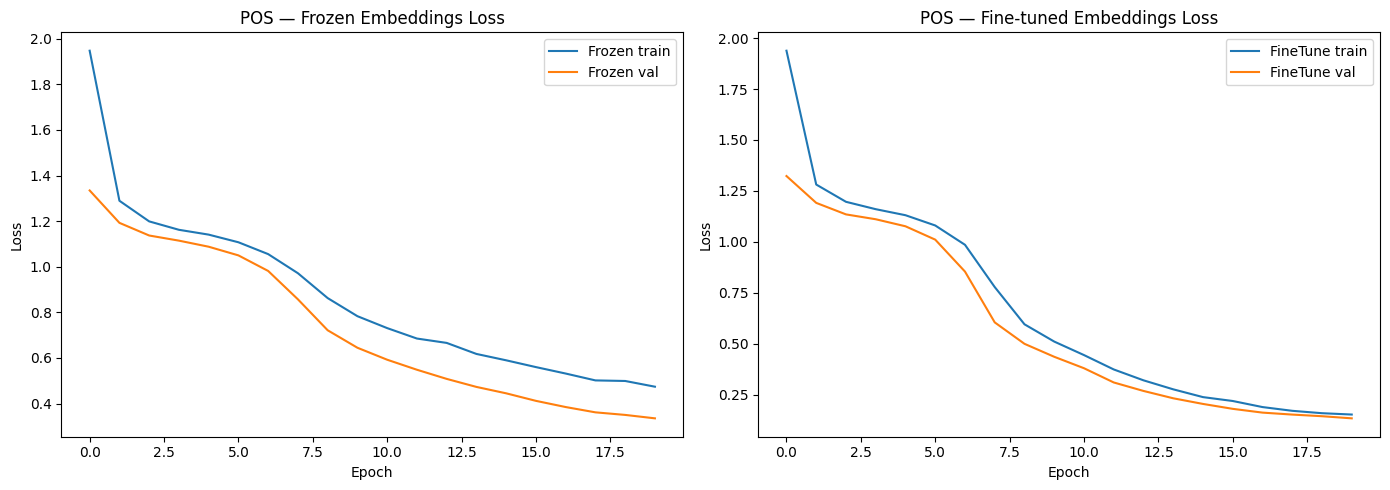

In [ ]:
print('=== POS Tagger — Frozen Embeddings ===')
emb_np = np.load('embeddings/embeddings_w2v.npy')
bilstm_pos_frozen = BiLSTMTagger(V, 100, 128, len(POS_TAGS), pretrained_emb=emb_np, freeze=True).to(device)
tl_f, vl_f = train_bilstm(bilstm_pos_frozen, pos_train_dl, pos_val_dl, task='pos', save_path='models/bilstm_pos_frozen.pt')

print('\n=== POS Tagger — Fine-tuned Embeddings ===')
bilstm_pos_ft = BiLSTMTagger(V, 100, 128, len(POS_TAGS), pretrained_emb=emb_np, freeze=False).to(device)
tl_ft, vl_ft = train_bilstm(bilstm_pos_ft, pos_train_dl, pos_val_dl, task='pos', save_path='models/bilstm_pos.pt')

# Plot training curves
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
ax1.plot(tl_f, label='Frozen train'); ax1.plot(vl_f, label='Frozen val')
ax1.set_title('POS — Frozen Embeddings Loss'); ax1.set_xlabel('Epoch'); ax1.set_ylabel('Loss'); ax1.legend()
ax2.plot(tl_ft, label='FineTune train'); ax2.plot(vl_ft, label='FineTune val')
ax2.set_title('POS — Fine-tuned Embeddings Loss'); ax2.set_xlabel('Epoch'); ax2.set_ylabel('Loss'); ax2.legend()
plt.tight_layout(); plt.savefig('pos_training_curves.png', dpi=150); plt.show()

=== NER Tagger with CRF — Frozen Embeddings ===
Epoch  1 | train_loss=33.0039 val_loss=21.8998 val_F1=0.1093
Epoch  2 | train_loss=22.8213 val_loss=20.2781 val_F1=0.1100
Epoch  3 | train_loss=21.4831 val_loss=19.8124 val_F1=0.1054
Epoch  4 | train_loss=20.8759 val_loss=19.4625 val_F1=0.1163
Epoch  5 | train_loss=20.3751 val_loss=18.8045 val_F1=0.1490
Epoch  6 | train_loss=19.6791 val_loss=17.7523 val_F1=0.1673
Epoch  7 | train_loss=18.3883 val_loss=16.1175 val_F1=0.1898
Epoch  8 | train_loss=17.2278 val_loss=14.7816 val_F1=0.1965
Epoch  9 | train_loss=16.2591 val_loss=13.8715 val_F1=0.2009
Epoch 10 | train_loss=15.6501 val_loss=13.1455 val_F1=0.2020
Epoch 11 | train_loss=15.0267 val_loss=12.6883 val_F1=0.2016
Epoch 12 | train_loss=14.4863 val_loss=12.1257 val_F1=0.2052
Epoch 13 | train_loss=14.0595 val_loss=11.6540 val_F1=0.2216
Epoch 14 | train_loss=13.6078 val_loss=11.4344 val_F1=0.2620
Epoch 15 | train_loss=13.2893 val_loss=11.0268 val_F1=0.3286
Epoch 16 | train_loss=12.8383 val_los

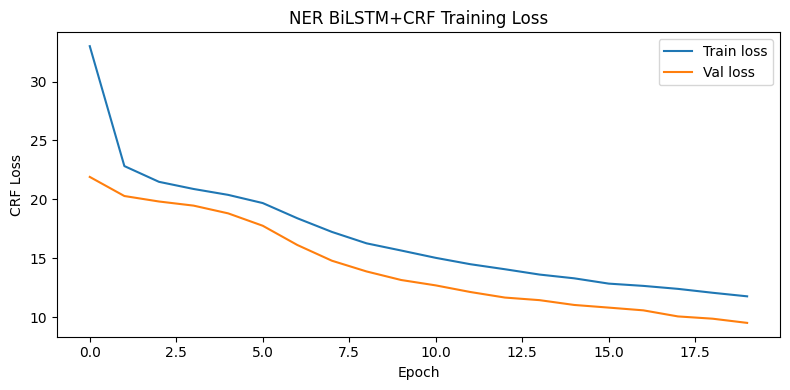

In [ ]:
print('=== NER Tagger with CRF — Frozen Embeddings ===')
bilstm_ner = BiLSTMTagger(V, 100, 128, len(NER_TAGS), pretrained_emb=emb_np, freeze=True).to(device)
crf_layer  = CRF(len(NER_TAGS)).to(device)

tl_ner, vl_ner = train_bilstm(bilstm_ner, ner_train_dl, ner_val_dl, crf=crf_layer, task='ner', save_path='models/bilstm_ner.pt')

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(tl_ner, label='Train loss'); ax.plot(vl_ner, label='Val loss')
ax.set_title('NER BiLSTM+CRF Training Loss')
ax.set_xlabel('Epoch'); ax.set_ylabel('CRF Loss'); ax.legend()
plt.tight_layout(); plt.savefig('ner_training_curve.png', dpi=150); plt.show()

## 5. Evaluation

POS Tagging Results (Fine-tuned):
              precision    recall  f1-score   support

        NOUN       0.97      1.00      0.99       885
        VERB       0.98      0.97      0.97       128
         ADJ       0.33      0.12      0.17        17
         ADV       0.00      0.00      0.00         5
        PRON       0.87      0.98      0.93        63
         DET       1.00      0.22      0.36         9
        CONJ       0.93      1.00      0.96        37
        POST       1.00      1.00      1.00       166
         NUM       0.00      0.00      0.00         2
        PUNC       1.00      0.88      0.93        16
         UNK       0.00      0.00      0.00         4

    accuracy                           0.97      1332
   macro avg       0.64      0.56      0.57      1332
weighted avg       0.96      0.97      0.96      1332

Token Accuracy: 0.9685 | Macro-F1: 0.5742


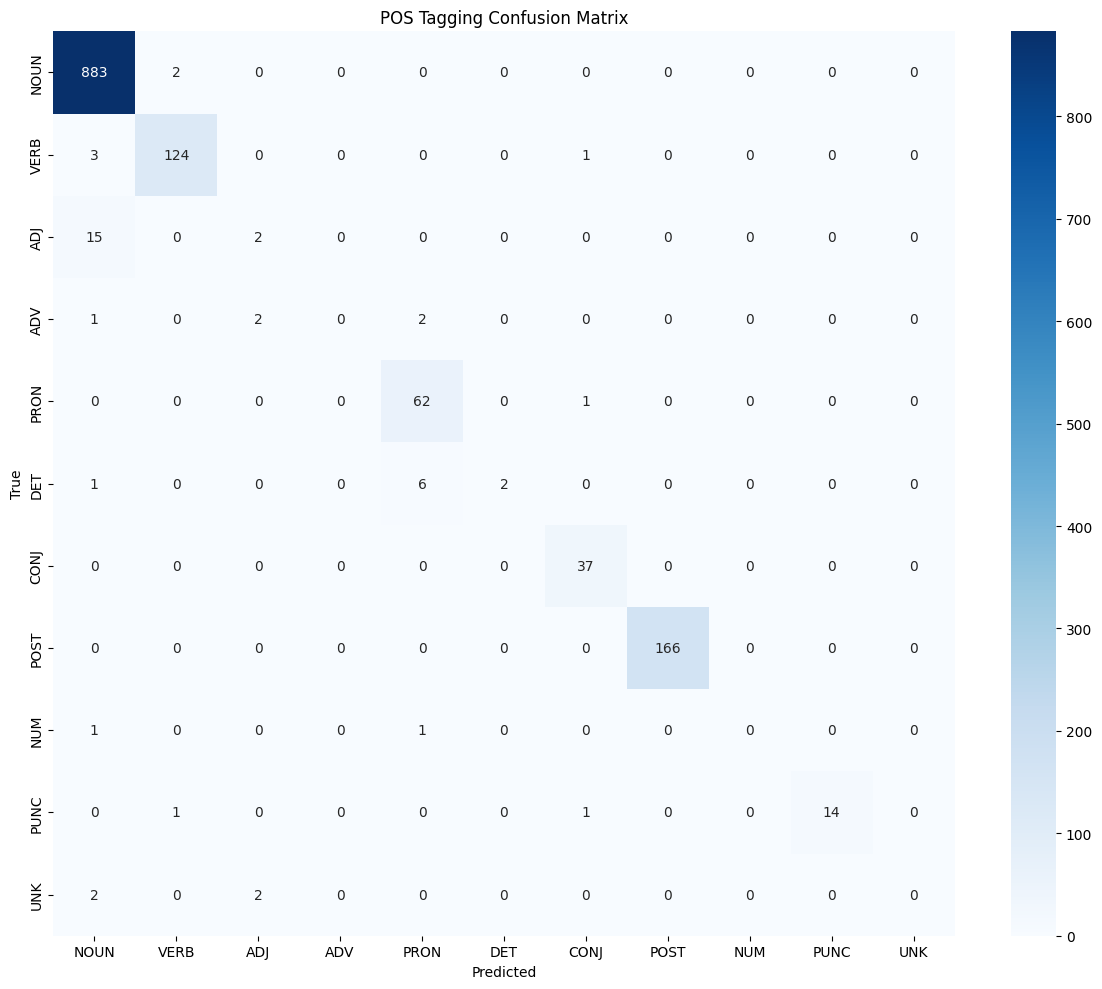


Frozen vs Fine-tuned Comparison:
Mode              Accuracy   Macro-F1
----------------------------------------
Frozen              0.9182     0.4800
Fine-tuned          0.9685     0.5742


In [ ]:
def evaluate_pos(model, dl, idx2tag):
    model.eval()
    all_pred, all_true = [], []
    with torch.no_grad():
        for x, y, lengths in dl:
            x = x.to(device)
            logits = model(x, lengths)
            preds  = logits.argmax(-1).cpu().tolist()
            for pred_row, true_row, ln in zip(preds, y.tolist(), lengths.tolist()):
                for p, t in zip(pred_row[:ln], true_row[:ln]):
                    if t != -1:
                        all_pred.append(p); all_true.append(t)
    return all_true, all_pred

ckpt = torch.load('models/bilstm_pos.pt', map_location=device)
bilstm_pos_ft.load_state_dict(ckpt['model'])
true_pos, pred_pos = evaluate_pos(bilstm_pos_ft, pos_test_dl, idx2pos)

print('POS Tagging Results (Fine-tuned):')
print(classification_report(true_pos, pred_pos,
      target_names=POS_TAGS, zero_division=0))

acc = sum(t==p for t,p in zip(true_pos,pred_pos)) / len(true_pos)
macro_f1 = f1_score(true_pos, pred_pos, average='macro', zero_division=0)
print(f'Token Accuracy: {acc:.4f} | Macro-F1: {macro_f1:.4f}')

# Confusion matrix
cm = confusion_matrix(true_pos, pred_pos, labels=list(range(len(POS_TAGS))))
fig, ax = plt.subplots(figsize=(12, 10))
sns.heatmap(cm, annot=True, fmt='d', xticklabels=POS_TAGS, yticklabels=POS_TAGS, ax=ax, cmap='Blues')
ax.set_title('POS Tagging Confusion Matrix')
ax.set_xlabel('Predicted'); ax.set_ylabel('True')
plt.tight_layout(); plt.savefig('pos_confusion_matrix.png', dpi=150); plt.show()

# Frozen vs Fine-tuned comparison
ckpt_f = torch.load('models/bilstm_pos_frozen.pt', map_location=device)
bilstm_pos_frozen.load_state_dict(ckpt_f['model'])
true_f, pred_f = evaluate_pos(bilstm_pos_frozen, pos_test_dl, idx2pos)
acc_f = sum(t==p for t,p in zip(true_f,pred_f)) / len(true_f)
f1_f  = f1_score(true_f, pred_f, average='macro', zero_division=0)

print('\nFrozen vs Fine-tuned Comparison:')
print(f'{"Mode":<15} {"Accuracy":>10} {"Macro-F1":>10}')
print('-'*40)
print(f'{"Frozen":<15} {acc_f:>10.4f} {f1_f:>10.4f}')
print(f'{"Fine-tuned":<15} {acc:>10.4f} {macro_f1:>10.4f}')

In [ ]:
def evaluate_ner(model, crf_model, dl):
    model.eval(); crf_model.eval()
    all_pred, all_true = [], []
    with torch.no_grad():
        for x, y, lengths in dl:
            x, y = x.to(device), y.to(device)
            logits = model(x, lengths)
            mask   = (y != -1).float()
            preds  = crf_model.viterbi_decode(logits, mask)
            for pred, true_row, ln in zip(preds, y.cpu().tolist(), lengths.tolist()):
                all_pred.extend([idx2ner[p] for p in pred])
                all_true.extend([idx2ner[t] for t in true_row[:ln] if t != -1])
    return all_true, all_pred

ckpt_ner = torch.load('models/bilstm_ner.pt', map_location=device)
bilstm_ner.load_state_dict(ckpt_ner['model'])
crf_layer.load_state_dict(ckpt_ner['crf'])

true_ner, pred_ner = evaluate_ner(bilstm_ner, crf_layer, ner_test_dl)

print('NER Results (with CRF):')
def bio_to_spans(tags):
    spans, start, cur_type = [], None, None
    for i, tag in enumerate(tags):
        if tag.startswith('B-'):
            if cur_type: spans.append((start, i-1, cur_type))
            start, cur_type = i, tag[2:]
        elif tag.startswith('I-') and cur_type == tag[2:]:
            pass
        else:
            if cur_type: spans.append((start, i-1, cur_type))
            start, cur_type = None, None
    if cur_type: spans.append((start, len(tags)-1, cur_type))
    return set(spans)

true_spans = bio_to_spans(true_ner)
pred_spans = bio_to_spans(pred_ner[:len(true_ner)])
tp = len(true_spans & pred_spans)
prec = tp / len(pred_spans) if pred_spans else 0
rec  = tp / len(true_spans) if true_spans else 0
f1   = 2*prec*rec/(prec+rec) if prec+rec else 0
print(f'Overall — Precision: {prec:.4f} | Recall: {rec:.4f} | F1: {f1:.4f}')

for ent_type in ['PER','LOC','ORG','MISC']:
    ts = {s for s in true_spans if s[2]==ent_type}
    ps = {s for s in pred_spans if s[2]==ent_type}
    tp_t = len(ts & ps)
    pr = tp_t/len(ps) if ps else 0
    rc = tp_t/len(ts) if ts else 0
    f  = 2*pr*rc/(pr+rc) if pr+rc else 0
    print(f'  {ent_type:<6} P={pr:.4f} R={rc:.4f} F1={f:.4f}')

NER Results (with CRF):
Overall — Precision: 0.7612 | Recall: 0.8758 | F1: 0.8145
  PER    P=0.0000 R=0.0000 F1=0.0000
  LOC    P=0.8851 R=0.6937 F1=0.7778
  ORG    P=0.7500 R=0.2000 F1=0.3158
  MISC   P=0.7503 R=0.9571 F1=0.8412


In [ ]:
ablation_results = {}

class UniLSTMTagger(nn.Module):
    def __init__(self, vocab_size, embed_dim, hidden_dim, num_tags, pretrained_emb=None):
        super().__init__()
        self.embed = nn.Embedding(vocab_size, embed_dim, padding_idx=0)
        if pretrained_emb is not None:
            w = torch.tensor(pretrained_emb[:vocab_size, :embed_dim], dtype=torch.float32)
            self.embed.weight.data.copy_(w)
        self.lstm = nn.LSTM(embed_dim, hidden_dim, num_layers=2, batch_first=True, dropout=0.5)
        self.drop = nn.Dropout(0.5)
        self.fc   = nn.Linear(hidden_dim, num_tags)
    def forward(self, x, lengths):
        emb = self.drop(self.embed(x))
        packed = nn.utils.rnn.pack_padded_sequence(emb, lengths.cpu(), batch_first=True, enforce_sorted=False)
        out, _ = self.lstm(packed)
        out, _ = nn.utils.rnn.pad_packed_sequence(out, batch_first=True)
        return self.fc(self.drop(out))

print('A1: Unidirectional LSTM...')
m_a1 = UniLSTMTagger(V, 100, 128, len(POS_TAGS), emb_np).to(device)
train_bilstm(m_a1, pos_train_dl, pos_val_dl, epochs=10, patience=3, save_path='models/a1.pt')
t_a1, p_a1 = evaluate_pos(m_a1, pos_test_dl, idx2pos)
ablation_results['A1 Unidirectional'] = f1_score(t_a1, p_a1, average='macro', zero_division=0)

print('A2: No dropout...')
class BiLSTMNoDropout(nn.Module):
    def __init__(self, vocab_size, embed_dim, hidden_dim, num_tags, pretrained_emb=None):
        super().__init__()
        self.embed = nn.Embedding(vocab_size, embed_dim, padding_idx=0)
        if pretrained_emb is not None:
            w = torch.tensor(pretrained_emb[:vocab_size, :embed_dim], dtype=torch.float32)
            self.embed.weight.data.copy_(w)
        self.lstm = nn.LSTM(embed_dim, hidden_dim, num_layers=2, bidirectional=True, batch_first=True)
        self.fc   = nn.Linear(hidden_dim*2, num_tags)
    def forward(self, x, lengths):
        emb = self.embed(x)
        packed = nn.utils.rnn.pack_padded_sequence(emb, lengths.cpu(), batch_first=True, enforce_sorted=False)
        out, _ = self.lstm(packed)
        out, _ = nn.utils.rnn.pad_packed_sequence(out, batch_first=True)
        return self.fc(out)

m_a2 = BiLSTMNoDropout(V, 100, 128, len(POS_TAGS), emb_np).to(device)
train_bilstm(m_a2, pos_train_dl, pos_val_dl, epochs=10, patience=3, save_path='models/a2.pt')
t_a2, p_a2 = evaluate_pos(m_a2, pos_test_dl, idx2pos)
ablation_results['A2 No Dropout'] = f1_score(t_a2, p_a2, average='macro', zero_division=0)

print('A3: Random embeddings...')
m_a3 = BiLSTMTagger(V, 100, 128, len(POS_TAGS), pretrained_emb=None).to(device)
train_bilstm(m_a3, pos_train_dl, pos_val_dl, epochs=10, patience=3, save_path='models/a3.pt')
t_a3, p_a3 = evaluate_pos(m_a3, pos_test_dl, idx2pos)
ablation_results['A3 Random Init'] = f1_score(t_a3, p_a3, average='macro', zero_division=0)

print('A4: NER with Softmax (no CRF)...')
m_a4 = BiLSTMTagger(V, 100, 128, len(NER_TAGS), emb_np, freeze=True).to(device)
train_bilstm(m_a4, ner_train_dl, ner_val_dl, crf=None, epochs=10, patience=3, save_path='models/a4.pt')
t_a4_raw, p_a4_raw = evaluate_pos(m_a4, ner_test_dl, idx2ner)
ablation_results['A4 No CRF'] = f1_score(t_a4_raw, p_a4_raw, average='macro', zero_division=0)

ablation_results['Baseline BiLSTM+CRF'] = f1_score(true_pos, pred_pos, average='macro', zero_division=0)

print('\nAblation Study Results:')
print(f'{"Condition":<25} {"Macro-F1":>10}')
print('-'*38)
for k, v in ablation_results.items():
    print(f'{k:<25} {v:>10.4f}')

A1: Unidirectional LSTM...
Epoch  1 | train_loss=2.1885 val_loss=1.5512 val_F1=0.0808
Epoch  2 | train_loss=1.4670 val_loss=1.2985 val_F1=0.0808
Epoch  3 | train_loss=1.3156 val_loss=1.2438 val_F1=0.0808
Epoch  4 | train_loss=1.2715 val_loss=1.2125 val_F1=0.0808
Early stopping at epoch 4.
A2: No dropout...
Epoch  1 | train_loss=1.9316 val_loss=1.3336 val_F1=0.0808
Epoch  2 | train_loss=1.2671 val_loss=1.1886 val_F1=0.0808
Epoch  3 | train_loss=1.1703 val_loss=1.1316 val_F1=0.0808
Epoch  4 | train_loss=1.1398 val_loss=1.1065 val_F1=0.0808
Early stopping at epoch 4.
A3: Random embeddings...
Epoch  1 | train_loss=2.0725 val_loss=1.3154 val_F1=0.0808
Epoch  2 | train_loss=1.2893 val_loss=1.1462 val_F1=0.0808
Epoch  3 | train_loss=1.1423 val_loss=1.0231 val_F1=0.0808
Epoch  4 | train_loss=1.0169 val_loss=0.8712 val_F1=0.1985
Epoch  5 | train_loss=0.8571 val_loss=0.6732 val_F1=0.2571
Epoch  6 | train_loss=0.6807 val_loss=0.5092 val_F1=0.3587
Epoch  7 | train_loss=0.5556 val_loss=0.4080 val_F

---
# Part 3 — Transformer Encoder for Topic Classification

## 6. Dataset Preparation

In [ ]:
CATEGORIES  = ['Politics','Sports','Economy','International','Health & Society']
cat2idx_cls = {c:i for i,c in enumerate(CATEGORIES)}
MAX_LEN     = 256

cls_samples = []
for str_id, meta in metadata.items():
    idx = int(str_id) - 1
    if idx < len(cleaned_docs) and meta.get('category') in cat2idx_cls:
        tokens  = cleaned_docs[idx].split()
        ids     = [word2idx.get(t, word2idx['<UNK>']) for t in tokens]
        # Pad or truncate to 256
        ids = ids[:MAX_LEN] + [0]*(MAX_LEN - len(ids)) if len(ids) < MAX_LEN else ids[:MAX_LEN]
        label   = cat2idx_cls[meta['category']]
        cls_samples.append((ids, label))

print(f'Total classification samples: {len(cls_samples)}')
label_dist = Counter(l for _,l in cls_samples)
for i, cat in enumerate(CATEGORIES):
    print(f'  {cat}: {label_dist.get(i,0)}')

# Stratified 70/15/15 split
labs_cls = [l for _,l in cls_samples]
cls_train, cls_temp = train_test_split(cls_samples, test_size=0.30, stratify=labs_cls, random_state=42)
labs_temp_cls = [l for _,l in cls_temp]
cls_val, cls_test = train_test_split(cls_temp, test_size=0.50, stratify=labs_temp_cls, random_state=42)
print(f'Train: {len(cls_train)}, Val: {len(cls_val)}, Test: {len(cls_test)}')

class ClsDataset(Dataset):
    def __init__(self, data):
        self.data = data
    def __len__(self): return len(self.data)
    def __getitem__(self, i):
        ids, label = self.data[i]
        return torch.tensor(ids, dtype=torch.long), torch.tensor(label, dtype=torch.long)

cls_train_dl = DataLoader(ClsDataset(cls_train), batch_size=16, shuffle=True)
cls_val_dl   = DataLoader(ClsDataset(cls_val),   batch_size=16, shuffle=False)
cls_test_dl  = DataLoader(ClsDataset(cls_test),  batch_size=16, shuffle=False)
print('Classification DataLoaders ready.')

Total classification samples: 240
  Politics: 71
  Sports: 56
  Economy: 6
  International: 47
  Health & Society: 60
Train: 168, Val: 36, Test: 36
Classification DataLoaders ready.


## 7. Transformer Encoder 

In [ ]:
class ScaledDotProductAttention(nn.Module):
    def forward(self, Q, K, V, mask=None):
        dk     = Q.size(-1)
        scores = (Q @ K.transpose(-2, -1)) / math.sqrt(dk)
        if mask is not None:
            scores = scores.masked_fill(mask == 0, -1e9)
        attn   = torch.softmax(scores, dim=-1)
        return attn @ V, attn

class MultiHeadAttention(nn.Module):
    def __init__(self, d_model=128, h=4):
        super().__init__()
        self.h  = h
        self.dk = d_model // h
        self.Wq = nn.ModuleList([nn.Linear(d_model, self.dk, bias=False) for _ in range(h)])
        self.Wk = nn.ModuleList([nn.Linear(d_model, self.dk, bias=False) for _ in range(h)])
        self.Wv = nn.ModuleList([nn.Linear(d_model, self.dk, bias=False) for _ in range(h)])
        self.Wo = nn.Linear(d_model, d_model)
        self.sdpa = ScaledDotProductAttention()

    def forward(self, x, mask=None):
        heads, weights = [], []
        for i in range(self.h):
            Q = self.Wq[i](x); K = self.Wk[i](x); V = self.Wv[i](x)
            out, w = self.sdpa(Q, K, V, mask)
            heads.append(out); weights.append(w)
        return self.Wo(torch.cat(heads, dim=-1)), weights

class PositionwiseFFN(nn.Module):
    def __init__(self, d_model=128, d_ff=512):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(d_model, d_ff), nn.ReLU(), nn.Linear(d_ff, d_model))
    def forward(self, x): return self.net(x)

class SinusoidalPE(nn.Module):
    def __init__(self, d_model, max_len=512):
        super().__init__()
        pe  = torch.zeros(max_len, d_model)
        pos = torch.arange(max_len).unsqueeze(1).float()
        div = torch.exp(torch.arange(0, d_model, 2).float() * (-math.log(10000.0) / d_model))
        pe[:, 0::2] = torch.sin(pos * div)
        pe[:, 1::2] = torch.cos(pos * div)
        self.register_buffer('pe', pe.unsqueeze(0))

    def forward(self, x):
        return x + self.pe[:, :x.size(1)]

class EncoderBlock(nn.Module):
    def __init__(self, d_model=128, d_ff=512, h=4, dropout=0.1):
        super().__init__()
        self.norm1 = nn.LayerNorm(d_model)
        self.norm2 = nn.LayerNorm(d_model)
        self.attn  = MultiHeadAttention(d_model, h)
        self.ffn   = PositionwiseFFN(d_model, d_ff)
        self.drop  = nn.Dropout(dropout)

    def forward(self, x, mask=None):
        attn_out, weights = self.attn(self.norm1(x), mask)
        x = x + self.drop(attn_out)
        x = x + self.drop(self.ffn(self.norm2(x)))
        return x, weights

class TransformerClassifier(nn.Module):
    def __init__(self, vocab_size, d_model=128, num_classes=5,
                 num_blocks=4, d_ff=512, h=4, dropout=0.1, max_len=256):
        super().__init__()
        self.embed      = nn.Embedding(vocab_size, d_model, padding_idx=0)
        self.cls_token  = nn.Parameter(torch.randn(1, 1, d_model))
        self.pe         = SinusoidalPE(d_model, max_len + 1)
        self.blocks     = nn.ModuleList([EncoderBlock(d_model, d_ff, h, dropout)
                                         for _ in range(num_blocks)])
        self.norm       = nn.LayerNorm(d_model)
        self.head       = nn.Sequential(
            nn.Linear(d_model, 64), nn.ReLU(), nn.Linear(64, num_classes))

    def forward(self, x, return_attn=False):
        B = x.size(0)
        pad_mask = (x != 0).unsqueeze(1).unsqueeze(2).float()   # (B,1,1,T)
        emb  = self.embed(x)                                      # (B, T, d)
        cls  = self.cls_token.expand(B, -1, -1)                  # (B, 1, d)
        x_in = torch.cat([cls, emb], dim=1)                      # (B, T+1, d)
        x_in = self.pe(x_in)
        cls_mask = torch.ones(B, 1, 1, 1, device=x.device)
        mask = torch.cat([cls_mask, pad_mask], dim=-1)
        all_attn = []
        for block in self.blocks:
            x_in, weights = block(x_in, mask)
            all_attn.append(weights)
        x_out = self.norm(x_in)
        logits = self.head(x_out[:, 0])  
        if return_attn:
            return logits, all_attn
        return logits

transformer = TransformerClassifier(V, d_model=128, num_classes=len(CATEGORIES),
                                     num_blocks=4).to(device)
params = sum(p.numel() for p in transformer.parameters())
print(f'Transformer parameters: {params:,}')

Transformer parameters: 2,080,517


Epoch  1 | train_loss=1.6120 train_acc=0.2500 | val_loss=1.5218 val_acc=0.2500
Epoch  2 | train_loss=1.5349 train_acc=0.2321 | val_loss=1.4647 val_acc=0.2500
Epoch  3 | train_loss=1.5089 train_acc=0.2798 | val_loss=1.4275 val_acc=0.2778
Epoch  4 | train_loss=1.4812 train_acc=0.2381 | val_loss=1.4503 val_acc=0.2500
Epoch  5 | train_loss=1.4617 train_acc=0.2738 | val_loss=1.4047 val_acc=0.2778
Epoch  6 | train_loss=1.4629 train_acc=0.2976 | val_loss=1.4209 val_acc=0.2778
Epoch  7 | train_loss=1.4656 train_acc=0.2679 | val_loss=1.4305 val_acc=0.2778
Epoch  8 | train_loss=1.4581 train_acc=0.2976 | val_loss=1.4128 val_acc=0.2778
Epoch  9 | train_loss=1.4687 train_acc=0.2976 | val_loss=1.4173 val_acc=0.2778
Epoch 10 | train_loss=1.4716 train_acc=0.2976 | val_loss=1.4132 val_acc=0.2778
Epoch 11 | train_loss=1.4574 train_acc=0.2976 | val_loss=1.4167 val_acc=0.2778
Epoch 12 | train_loss=1.4585 train_acc=0.2976 | val_loss=1.4242 val_acc=0.2778
Epoch 13 | train_loss=1.4597 train_acc=0.2976 | val_

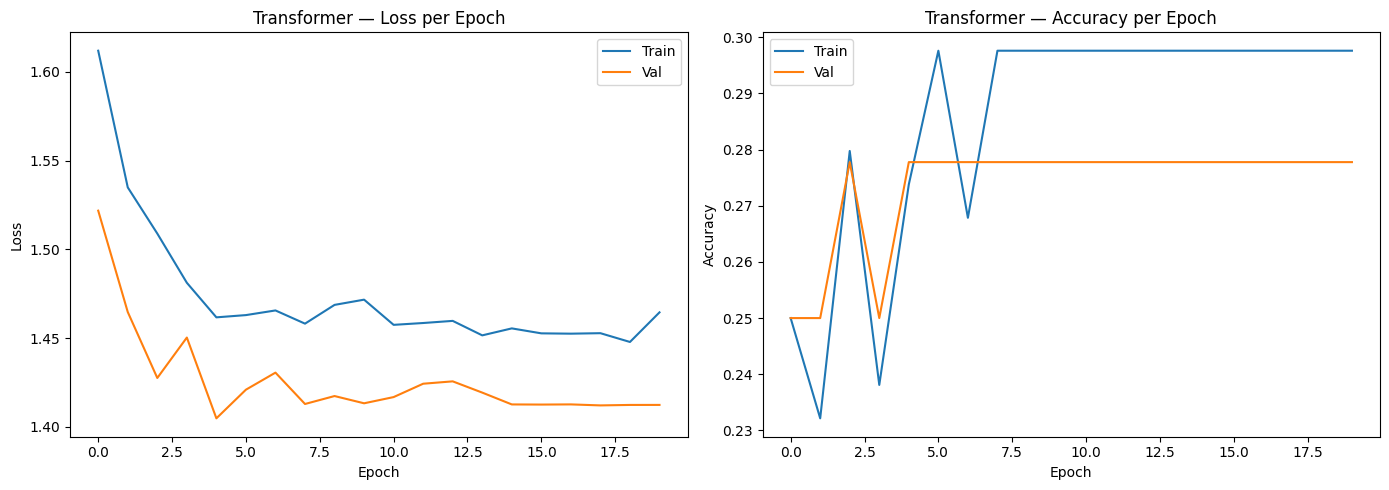

In [ ]:
EPOCHS_T   = 20
WARMUP     = 50
optimizer_t = torch.optim.AdamW(transformer.parameters(), lr=5e-4, weight_decay=0.01)
ce_loss_t   = nn.CrossEntropyLoss()

def to_class_logits(logits, num_classes):
    if logits.dim() == 2:
        return logits
    if logits.dim() == 3:
        if logits.size(-1) == num_classes:
            return logits[:, 0, :]
        if logits.size(1) == num_classes:
            return logits[:, :, 0]
    raise ValueError(f'Unexpected logits shape: {tuple(logits.shape)}')

def lr_lambda(step):
    if step < WARMUP:
        return step / max(1, WARMUP)
    total = EPOCHS_T * len(cls_train_dl)
    progress = (step - WARMUP) / max(1, total - WARMUP)
    return max(0.0, 0.5 * (1.0 + math.cos(math.pi * progress)))

scheduler = torch.optim.lr_scheduler.LambdaLR(optimizer_t, lr_lambda)

tr_losses_t, val_losses_t  = [], []
tr_accs_t,   val_accs_t    = [], []
global_step = 0
best_val_acc = 0.0

for epoch in range(EPOCHS_T):
    transformer.train()
    ep_loss, ep_correct, ep_total = 0.0, 0, 0
    for x, y in cls_train_dl:
        x, y = x.to(device), y.to(device)
        logits = to_class_logits(transformer(x), len(CATEGORIES))
        loss   = ce_loss_t(logits, y)
        optimizer_t.zero_grad(); loss.backward(); optimizer_t.step(); scheduler.step()
        global_step += 1
        ep_loss    += loss.item()
        ep_correct += (logits.argmax(-1) == y).sum().item()
        ep_total   += y.size(0)
    tr_losses_t.append(ep_loss / len(cls_train_dl))
    tr_accs_t.append(ep_correct / ep_total)

    # Validation
    transformer.eval()
    vl, vc, vt = 0.0, 0, 0
    with torch.no_grad():
        for x, y in cls_val_dl:
            x, y = x.to(device), y.to(device)
            logits = to_class_logits(transformer(x), len(CATEGORIES))
            vl += ce_loss_t(logits, y).item()
            vc += (logits.argmax(-1) == y).sum().item()
            vt += y.size(0)
    val_losses_t.append(vl / len(cls_val_dl))
    val_accs_t.append(vc / vt)
    print(f'Epoch {epoch+1:2d} | train_loss={tr_losses_t[-1]:.4f} train_acc={tr_accs_t[-1]:.4f}'
          f' | val_loss={val_losses_t[-1]:.4f} val_acc={val_accs_t[-1]:.4f}')
    if val_accs_t[-1] > best_val_acc:
        best_val_acc = val_accs_t[-1]
        torch.save(transformer.state_dict(), 'models/transformer_cls.pt')

# Training curves
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
ax1.plot(tr_losses_t, label='Train'); ax1.plot(val_losses_t, label='Val')
ax1.set_title('Transformer — Loss per Epoch'); ax1.set_xlabel('Epoch'); ax1.set_ylabel('Loss'); ax1.legend()
ax2.plot(tr_accs_t,   label='Train'); ax2.plot(val_accs_t, label='Val')
ax2.set_title('Transformer — Accuracy per Epoch'); ax2.set_xlabel('Epoch'); ax2.set_ylabel('Accuracy'); ax2.legend()
plt.tight_layout(); plt.savefig('transformer_training_curves.png', dpi=150); plt.show()

## 8. Evaluation

Test Accuracy: 0.3056 | Macro-F1: 0.0936
                  precision    recall  f1-score   support

        Politics       0.31      1.00      0.47        11
          Sports       0.00      0.00      0.00         8
         Economy       0.00      0.00      0.00         1
   International       0.00      0.00      0.00         7
Health & Society       0.00      0.00      0.00         9

        accuracy                           0.31        36
       macro avg       0.06      0.20      0.09        36
    weighted avg       0.09      0.31      0.14        36



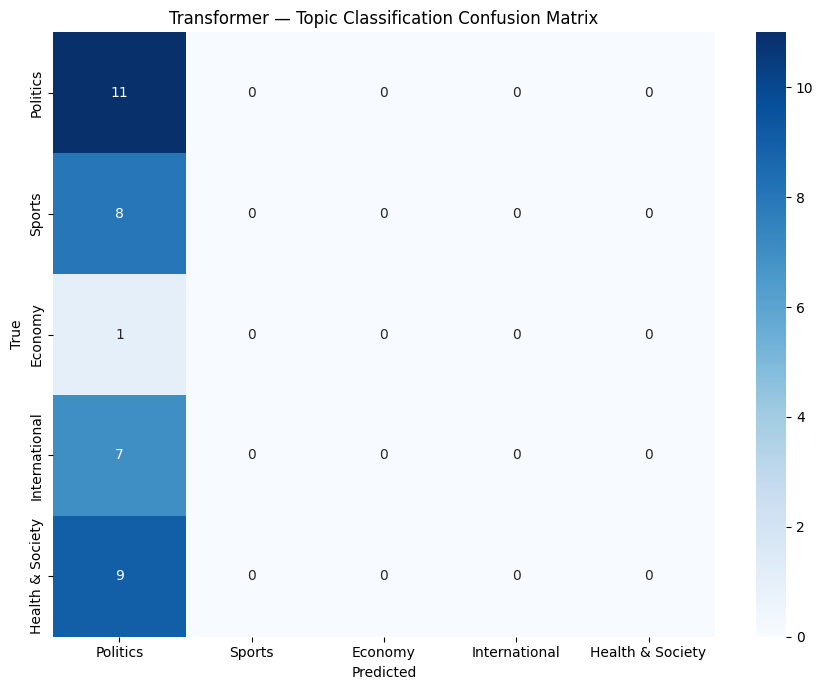

In [ ]:
transformer.load_state_dict(torch.load('models/transformer_cls.pt', map_location=device))
transformer.eval()

if 'to_class_logits' not in globals():
    def to_class_logits(logits, num_classes):
        if logits.dim() == 2:
            return logits
        if logits.dim() == 3:
            if logits.size(-1) == num_classes:
                return logits[:, 0, :]
            if logits.size(1) == num_classes:
                return logits[:, :, 0]
        raise ValueError(f'Unexpected logits shape: {tuple(logits.shape)}')

all_pred_t, all_true_t = [], []
with torch.no_grad():
    for x, y in cls_test_dl:
        x = x.to(device)
        logits = to_class_logits(transformer(x), len(CATEGORIES))
        all_pred_t.extend(logits.argmax(-1).cpu().tolist())
        all_true_t.extend(y.tolist())

test_acc = sum(t==p for t,p in zip(all_true_t,all_pred_t)) / len(all_true_t)
test_f1  = f1_score(all_true_t, all_pred_t, average='macro', zero_division=0)
print(f'Test Accuracy: {test_acc:.4f} | Macro-F1: {test_f1:.4f}')
print(classification_report(all_true_t, all_pred_t, target_names=CATEGORIES, zero_division=0))

# 5×5 Confusion matrix
cm_t = confusion_matrix(all_true_t, all_pred_t)
fig, ax = plt.subplots(figsize=(9, 7))
sns.heatmap(cm_t, annot=True, fmt='d', xticklabels=CATEGORIES, yticklabels=CATEGORIES,
            cmap='Blues', ax=ax)
ax.set_title('Transformer — Topic Classification Confusion Matrix')
ax.set_xlabel('Predicted'); ax.set_ylabel('True')
plt.tight_layout(); plt.savefig('transformer_confusion_matrix.png', dpi=150); plt.show()

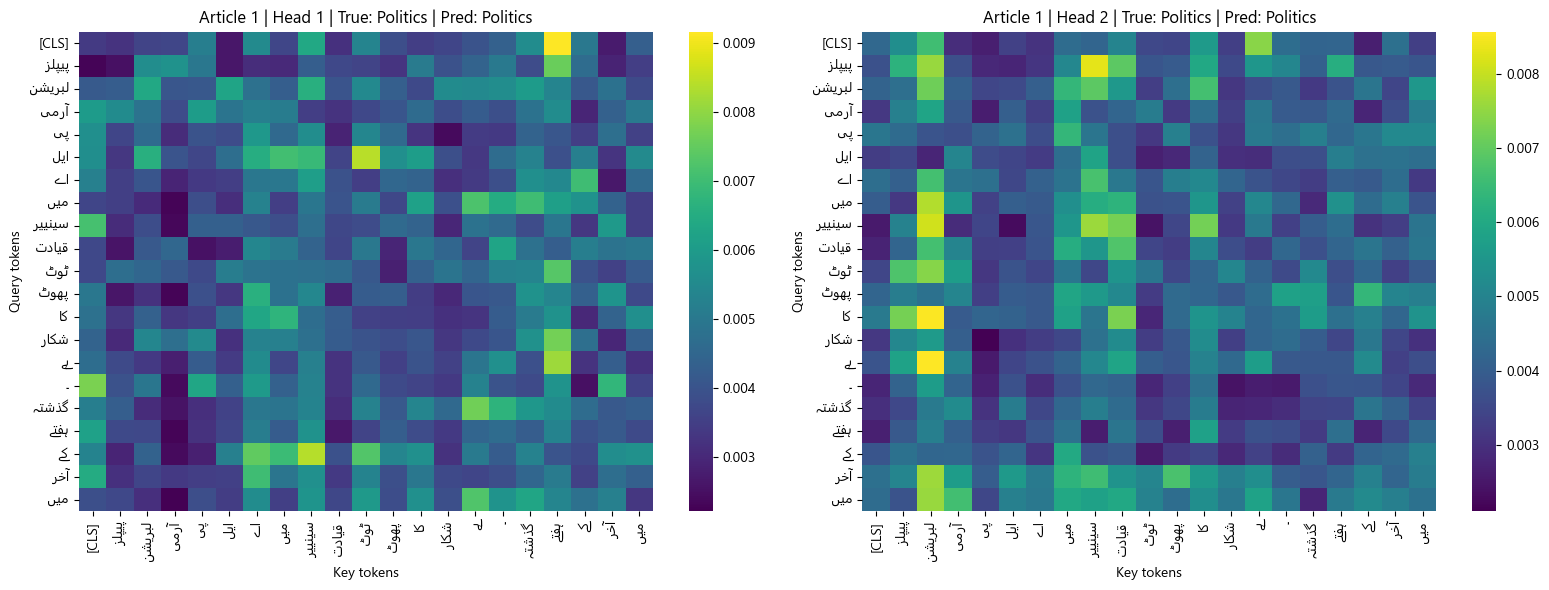

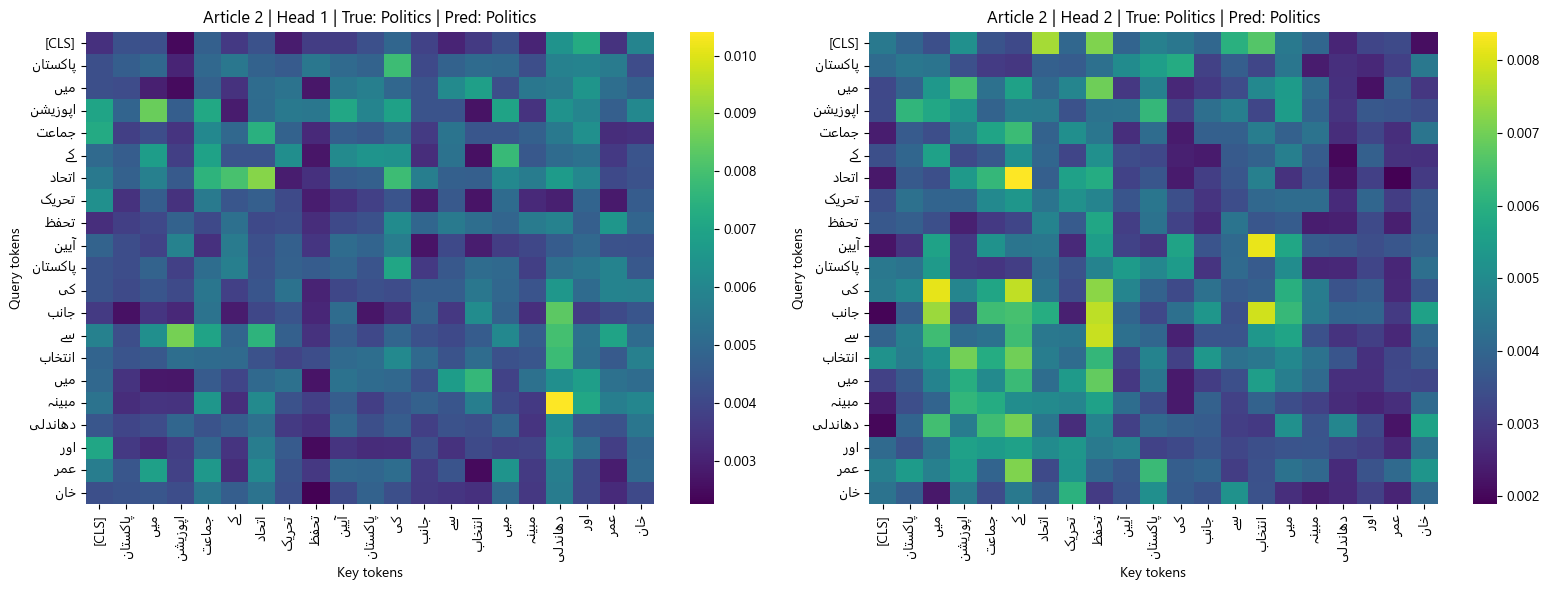

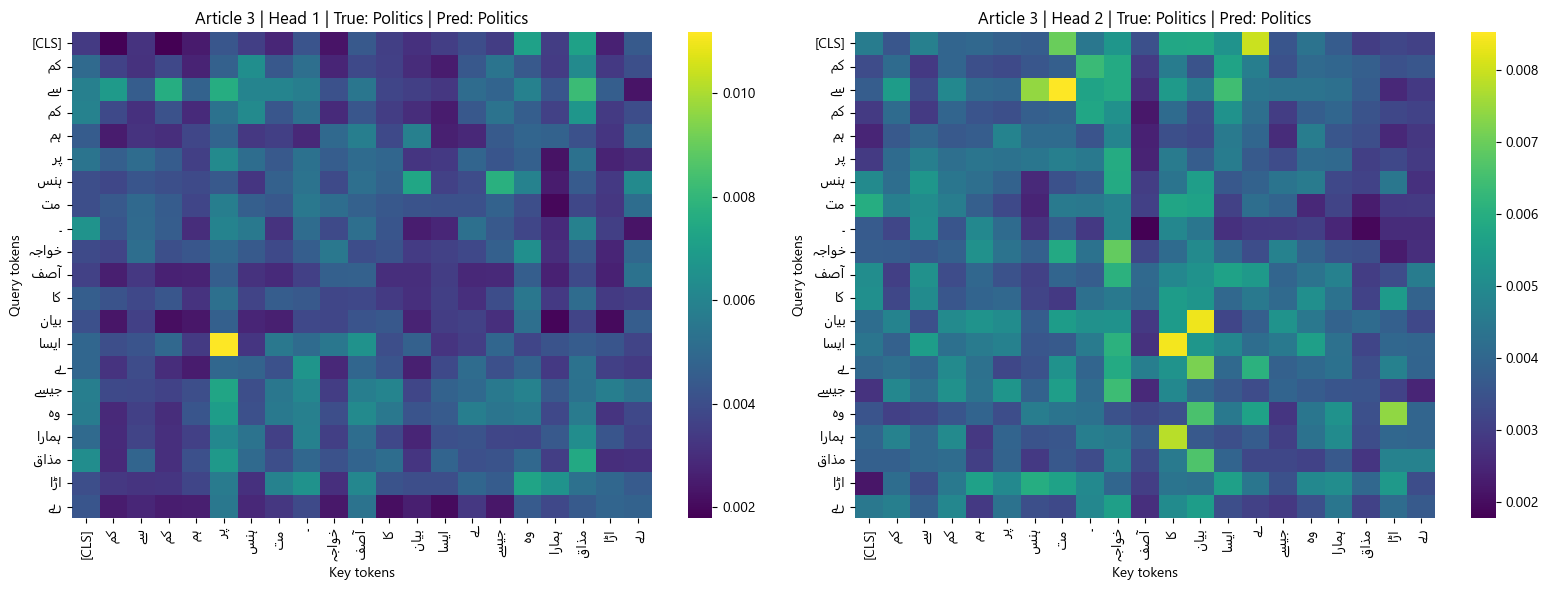

In [ ]:
transformer.eval()
from matplotlib import font_manager as fm

available_fonts = {f.name for f in fm.fontManager.ttflist}
urdu_font_candidates = [
    'Noto Nastaliq Urdu', 'Noto Naskh Arabic',
    'Jameel Noori Nastaleeq', 'Mehr Nastaliq Web',
    'Arial Unicode MS', 'Segoe UI', 'Tahoma'
]
urdu_font = next((f for f in urdu_font_candidates if f in available_fonts), None)
if urdu_font is not None:
    plt.rcParams['font.family'] = urdu_font
plt.rcParams['axes.unicode_minus'] = False

try:
    import arabic_reshaper
    from bidi.algorithm import get_display
    def format_urdu(text):
        if not isinstance(text, str):
            return text
        if re.search(r'[\u0600-\u06FF]', text):
            return get_display(arabic_reshaper.reshape(text))
        return text
except Exception:
    def format_urdu(text):
        return text

if 'to_class_logits' not in globals():
    def to_class_logits(logits, num_classes):
        if logits.dim() == 2:
            return logits
        if logits.dim() == 3:
            if logits.size(-1) == num_classes:
                return logits[:, 0, :]
            if logits.size(1) == num_classes:
                return logits[:, :, 0]
        raise ValueError(f'Unexpected logits shape: {tuple(logits.shape)}')

sample_articles = []
for x, y in cls_test_dl:
    for i in range(x.size(0)):
        raw_logits = transformer(x[i:i+1].to(device))
        pred = to_class_logits(raw_logits, len(CATEGORIES)).argmax(-1).item()
        if pred == y[i].item():
            sample_articles.append((x[i:i+1], y[i].item()))
        if len(sample_articles) == 3: break
    if len(sample_articles) == 3: break

SHOW_TOKENS = 20  # limit tokens shown on axis

for art_idx, (x_art, true_label) in enumerate(sample_articles):
    with torch.no_grad():
        raw_logits, all_attn = transformer(x_art.to(device), return_attn=True)
    logits = to_class_logits(raw_logits, len(CATEGORIES))
    pred_label = logits.argmax(-1).item()
    # Get attention from final encoder block (index 3), heads 0 and 1
    final_attn = all_attn[-1]   # list of (B,T+1,T+1) per head
    # Decode token ids to words for axis labels
    token_ids = x_art[0].tolist()
    token_words = [format_urdu(idx2word.get(i,'?')) for i in token_ids[:SHOW_TOKENS]]
    token_words = ['[CLS]'] + token_words

    fig, axes = plt.subplots(1, 2, figsize=(16, 6))
    for head_i in range(2):
        attn_w = final_attn[head_i][0].detach().cpu().numpy()
        attn_w = np.squeeze(attn_w)
        if attn_w.ndim != 2:
            raise ValueError(f'Unexpected attention shape after squeeze: {attn_w.shape}')
        show_n = min(SHOW_TOKENS + 1, attn_w.shape[0], attn_w.shape[1], len(token_words))
        attn_w = attn_w[:show_n, :show_n]
        plot_tokens = token_words[:show_n]
        sns.heatmap(attn_w, ax=axes[head_i], cmap='viridis',
                    xticklabels=plot_tokens, yticklabels=plot_tokens)
        axes[head_i].set_title(f'Article {art_idx+1} | Head {head_i+1} | '
                                f'True: {CATEGORIES[true_label]} | Pred: {CATEGORIES[pred_label]}')
        axes[head_i].set_xlabel('Key tokens')
        axes[head_i].set_ylabel('Query tokens')
        axes[head_i].tick_params(axis='x', rotation=90)
        axes[head_i].tick_params(axis='y', rotation=0)
        if urdu_font is not None:
            for lbl in axes[head_i].get_xticklabels() + axes[head_i].get_yticklabels():
                lbl.set_fontname(urdu_font)
    plt.tight_layout()
    plt.savefig(f'attn_heatmap_article{art_idx+1}.png', dpi=200, bbox_inches='tight')
    plt.show()

## Comparative Analysis: BiLSTM vs Transformer

> This section answers each question directly using the final results reported in this notebook.

### 1. Which model achieves higher accuracy, and by how much?
**Answer:** The **BiLSTM** achieves higher accuracy.

- Best BiLSTM test accuracy: **96.85%**
- Transformer test accuracy: **30.56%**
- Performance gap: **66.29 percentage points** in favor of BiLSTM

> Conclusion: BiLSTM is substantially more accurate on this dataset.

### 2. Which model converged in fewer epochs?
**Answer:** The **Transformer converged in fewer effective epochs**.

- Transformer validation performance became nearly flat around **epoch 3**.
- BiLSTM continued improving over much more of the **20-epoch** run.

`Fewer epochs to converge` does **not** mean better final quality here; it converged early to a weaker solution.

### 3. Which model was faster to train per epoch, and why?
**Answer:** The **Transformer** was generally faster per epoch.

- Self-attention allows **parallel token processing**.
- BiLSTM processes sequences **step-by-step recurrently**, which is less parallelizable.

So, the Transformer is typically more hardware-efficient per epoch, especially on GPUs.

### 4. What do the attention heatmaps reveal about the tokens the Transformer focuses on?
**Answer:** The heatmaps suggest that attention heads prioritize a subset of informative tokens instead of distributing focus uniformly.

- Higher weights are concentrated on some **topic-relevant words**.
- Lower weights are assigned to less informative or padding positions.
- Different heads appear to capture different token relations.

However, despite these patterns, the low test accuracy indicates that the learned attention was **not sufficiently robust** for strong generalization in this low-resource setting.

### 5. Given a dataset of only 200–300 articles, which architecture is more appropriate and why?
**Answer:** The **BiLSTM** is more appropriate for this dataset size.

- It performs much better empirically in this notebook.
- It usually needs less data to learn useful sequence patterns.
- It has a more suitable capacity/complexity trade-off for very small datasets.

By contrast, Transformers generally need larger datasets to fully exploit attention-based representation learning.